In [ ]:
import sys, os
# Adjust depth based on notebook location relative to project root
_src_path = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'src'))
if _src_path not in sys.path:
    sys.path.insert(0, _src_path)
from project_config import load_config

config    = load_config()
base_dir  = config['base_dir']
well_list = config['well_list']
well_meta = config.get('well_metadata', {})

print(f'Active experiment: {config.get("experiment_name", config.get("experiment_key", "?"))}')
print(f'Base dir: {base_dir}')

In [18]:
import os, re
import numpy as np
import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import scanpy as sc

# powerpoint
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_PARAGRAPH_ALIGNMENT

In [19]:
# --- paths ---
ROOT = r"Z:\Lauryn\Liposarcoma\Liposarcoma_2025\LPS_863_Abema_July_2025"
H5AD_PATH = os.path.join(ROOT, "pRb_2_split_analysis\standard_adata_sub.h5ad")
PPTX_PATH = os.path.join(ROOT, "Analysis PPTX", "Mdm2_nuc_histograms.pptx")

In [50]:
adata = sc.read_h5ad(H5AD_PATH)
print(adata)

FEATURE_COL = "pS6_S6_ratio"   # change anytime (MDM2, DNA, pRB, etc.)
SAMPLE_COL  = "sample_ID"
DRUG_COL    = "treatment"
DOSE_COL    = "dose"

AnnData object with n_obs × n_vars = 14000 × 92
    obs: 'label', 'well', 'sample_ID', 'dose', 'treatment', 'centroid-0', 'centroid-1', 'pRB_label', 'pRb_Rb_ratio'


In [49]:
adata.var_names[:120]

Index(['nuc_area', 'orientation', 'major_axis_length', 'minor_axis_length',
       'R0_pRb_nuc_mean', 'R0_Rb_nuc_mean', 'R0_CDK2_nuc_mean',
       'R1_CDK4_nuc_mean', 'R1_p53_nuc_mean', 'R1_p21_nuc_mean',
       'R2_cycD1_nuc_mean', 'R2_Mdm2_nuc_mean', 'R2_cycB1_nuc_mean',
       'R3_Ki67_nuc_mean', 'R3_p16_nuc_mean', 'R3_cycA2_nuc_mean',
       'R4_pS6_nuc_mean', 'R4_S6_nuc_mean', 'R5_DNA_nuc_mean',
       'R5_Cdt1_nuc_mean', 'R5_E2F1_nuc_mean', 'R0_DNA_ring_mean',
       'R0_pRb_ring_mean', 'R0_Rb_ring_mean', 'R0_CDK2_ring_mean',
       'R1_DNA_ring_mean', 'R1_CDK4_ring_mean', 'R1_p53_ring_mean',
       'R1_p21_ring_mean', 'R2_DNA_ring_mean', 'R2_cycD1_ring_mean',
       'R2_Mdm2_ring_mean', 'R2_cycB1_ring_mean', 'R3_DNA_ring_mean',
       'R3_Ki67_ring_mean', 'R3_p16_ring_mean', 'R3_cycA2_ring_mean',
       'R4_DNA_ring_mean', 'R4_pS6_ring_mean', 'R4_S6_ring_mean',
       'R5_DNA_ring_mean', 'R5_Cdt1_ring_mean', 'R5_E2F1_ring_mean',
       'R0_DNA_total_nuc_protein', 'R0_pRb_total_n

In [51]:
def get_feature_values(adata, feature):

    # Case 1: already in obs
    if feature in adata.obs.columns:
        return adata.obs[feature].astype(float)

    # Case 2: in var / X matrix
    if feature in adata.var_names:
        idx = list(adata.var_names).index(feature)

        if sp.issparse(adata.X):
            return adata.X[:, idx].toarray().ravel()
        else:
            return adata.X[:, idx]

    raise KeyError(f"{feature} not found in obs or var_names")

In [52]:
adata.obs[FEATURE_COL] = get_feature_values(adata, FEATURE_COL)

In [53]:
Z_SCORE = True

if Z_SCORE:
    vals = adata.obs[FEATURE_COL].astype(float).dropna().values
    mean, std = vals.mean(), vals.std()

    adata.obs[f"{FEATURE_COL}_z"] = (
        adata.obs[FEATURE_COL].astype(float) - mean
    ) / std

    feature_to_plot = f"{FEATURE_COL}_z"
else:
    feature_to_plot = FEATURE_COL

In [54]:
def make_histogram(adata, sample_id, bins=70):

    sub = adata.obs[adata.obs[SAMPLE_COL] == sample_id]
    if sub.empty:
        return None, None

    drug, dose = sub[DRUG_COL].iloc[0], sub[DOSE_COL].iloc[0]

    x = sub[feature_to_plot].dropna().values
    if x.size == 0:
        return None, None

    counts, edges = np.histogram(x, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths  = edges[1:] - edges[:-1]

    fig, ax = plt.subplots(figsize=(16,7))

    ax.bar(centers, counts, width=widths, edgecolor="black", alpha=0.85)

    ax.set_title(f"{drug} {dose} — Sample {sample_id} (N={len(x)})")
    ax.set_xlabel(feature_to_plot)
    ax.set_ylabel("Cell count")

    plt.tight_layout()
    plt.show()

    return fig

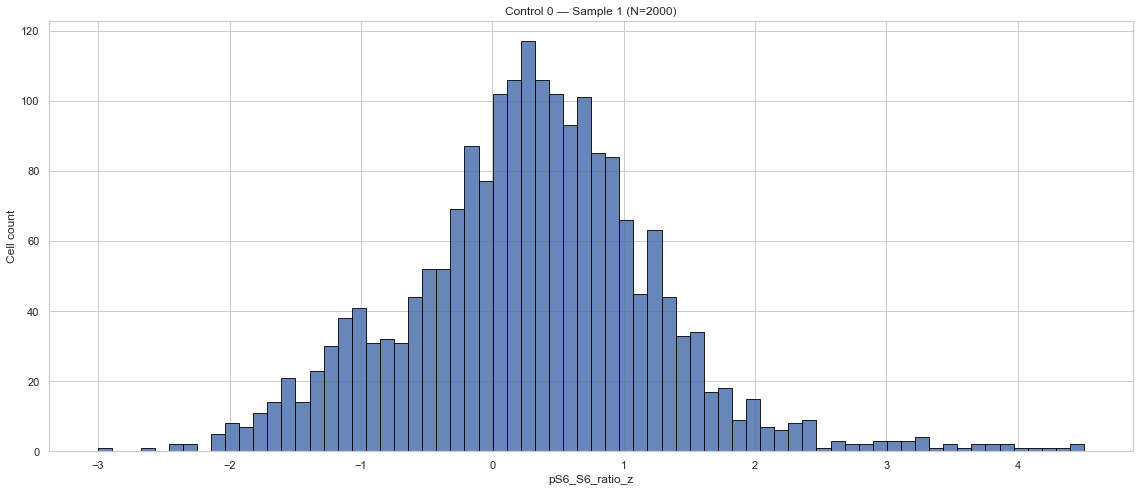

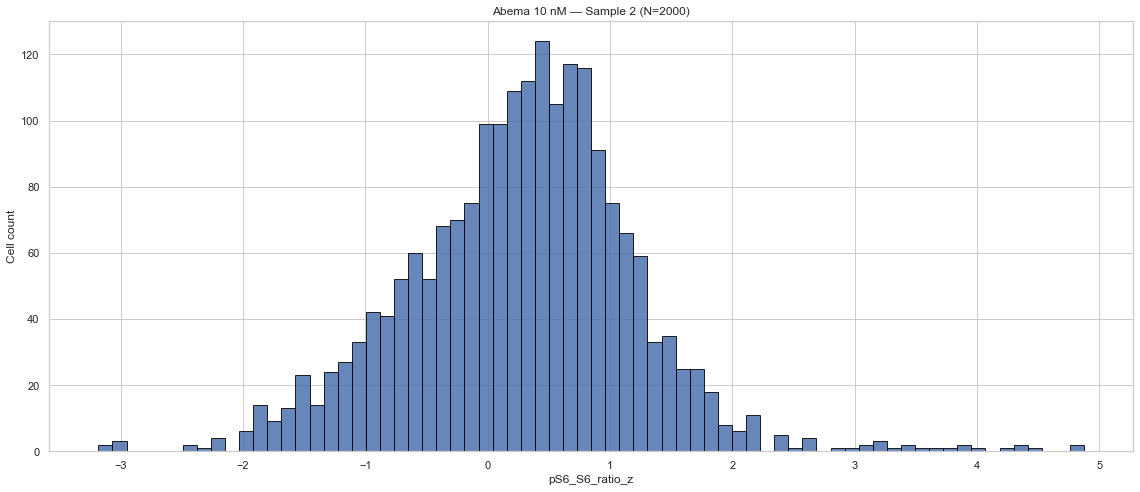

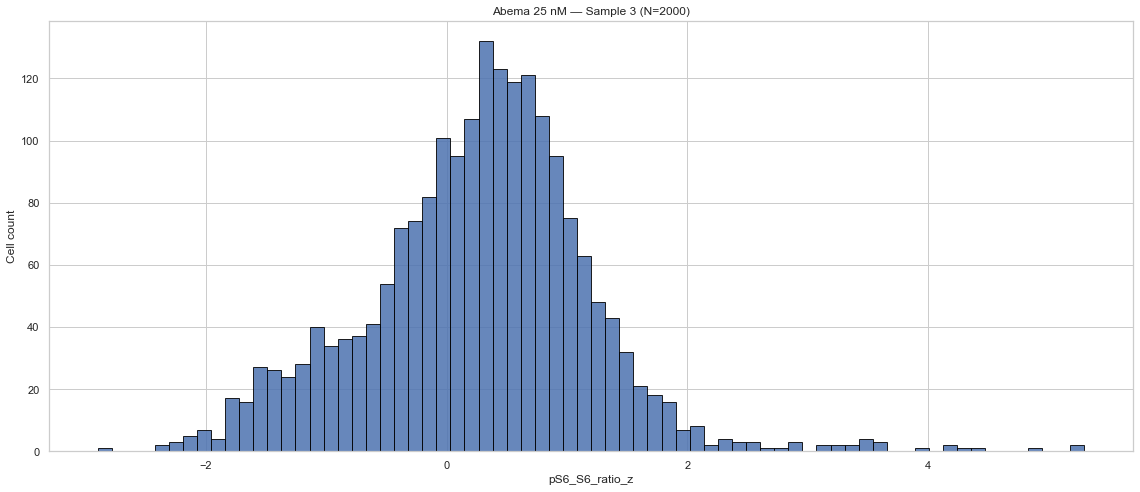

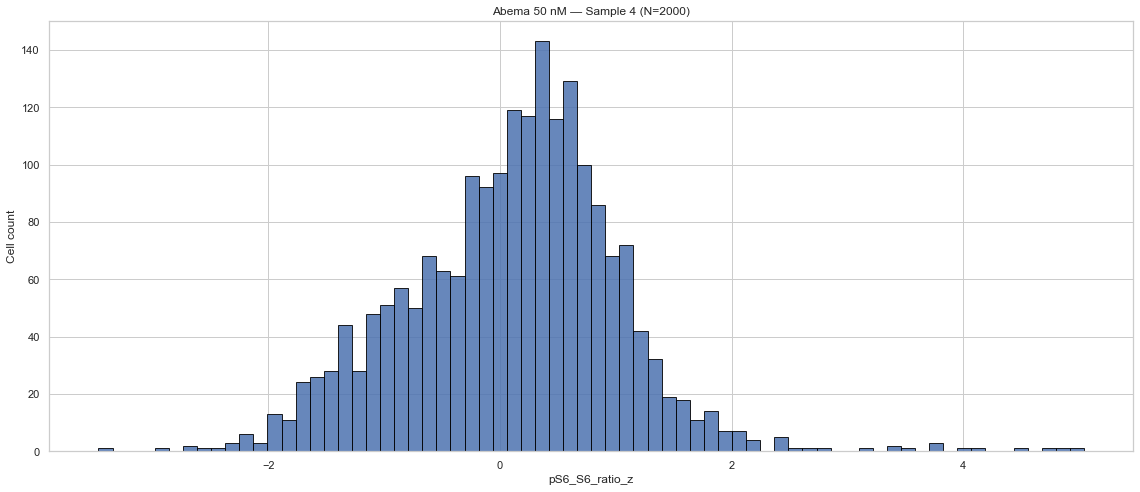

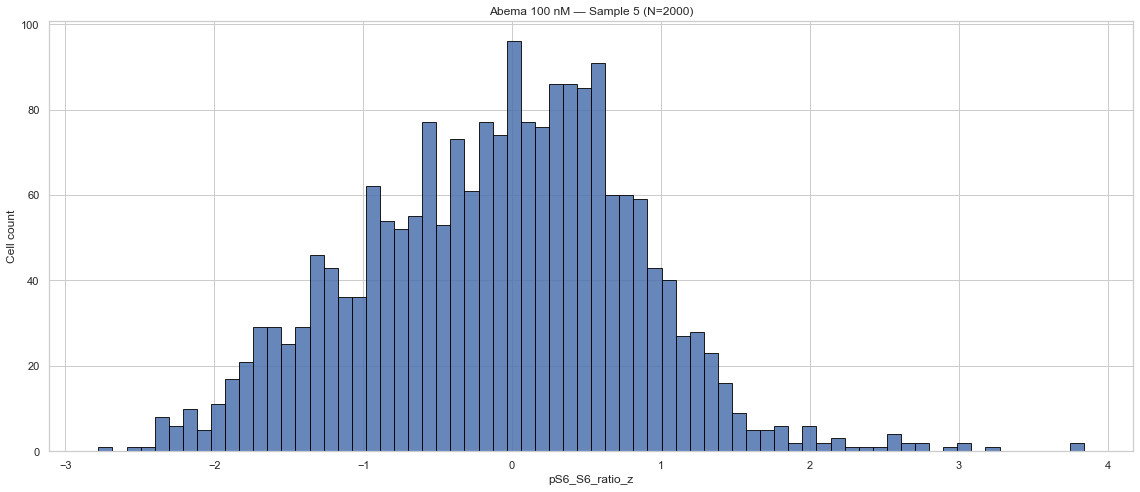

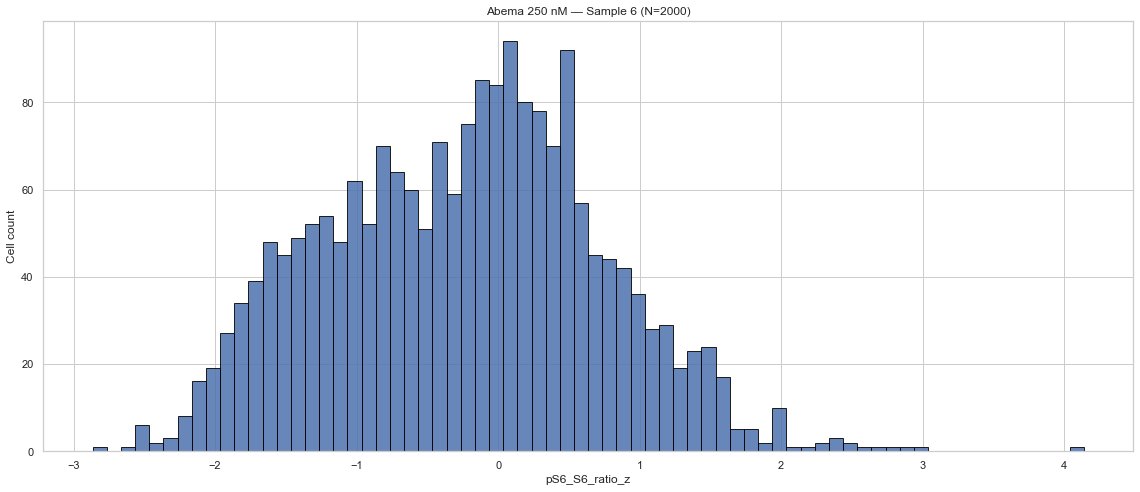

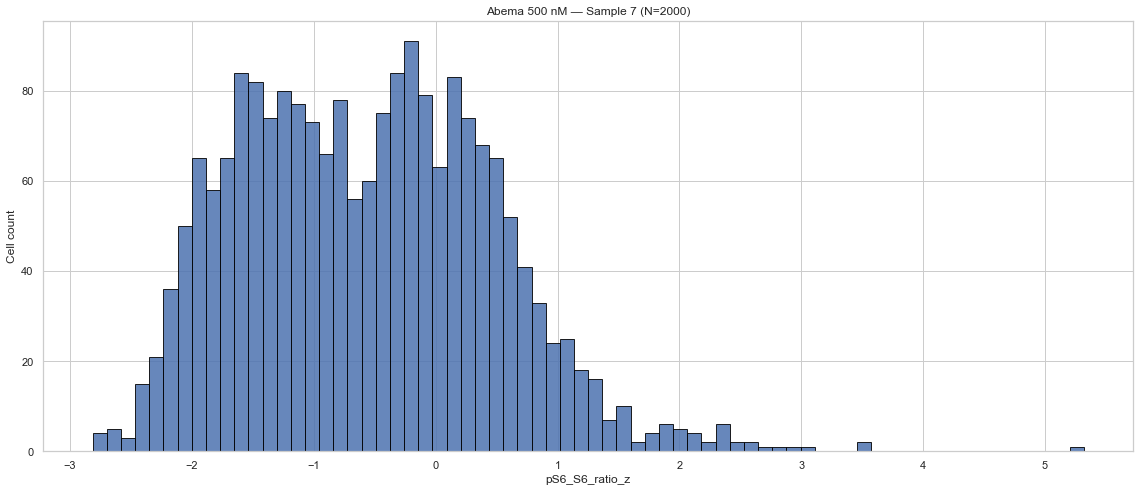

In [55]:
sample_ids = sorted(adata.obs[SAMPLE_COL].unique())

for sid in sample_ids:
    fig = make_histogram(adata, sid, bins=70)

In [59]:
adata.var_names[:120]

Index(['nuc_area', 'orientation', 'major_axis_length', 'minor_axis_length',
       'R0_pRb_nuc_mean', 'R0_Rb_nuc_mean', 'R0_CDK2_nuc_mean',
       'R1_CDK4_nuc_mean', 'R1_p53_nuc_mean', 'R1_p21_nuc_mean',
       'R2_cycD1_nuc_mean', 'R2_Mdm2_nuc_mean', 'R2_cycB1_nuc_mean',
       'R3_Ki67_nuc_mean', 'R3_p16_nuc_mean', 'R3_cycA2_nuc_mean',
       'R4_pS6_nuc_mean', 'R4_S6_nuc_mean', 'R5_DNA_nuc_mean',
       'R5_Cdt1_nuc_mean', 'R5_E2F1_nuc_mean', 'R0_DNA_ring_mean',
       'R0_pRb_ring_mean', 'R0_Rb_ring_mean', 'R0_CDK2_ring_mean',
       'R1_DNA_ring_mean', 'R1_CDK4_ring_mean', 'R1_p53_ring_mean',
       'R1_p21_ring_mean', 'R2_DNA_ring_mean', 'R2_cycD1_ring_mean',
       'R2_Mdm2_ring_mean', 'R2_cycB1_ring_mean', 'R3_DNA_ring_mean',
       'R3_Ki67_ring_mean', 'R3_p16_ring_mean', 'R3_cycA2_ring_mean',
       'R4_DNA_ring_mean', 'R4_pS6_ring_mean', 'R4_S6_ring_mean',
       'R5_DNA_ring_mean', 'R5_Cdt1_ring_mean', 'R5_E2F1_ring_mean',
       'R0_DNA_total_nuc_protein', 'R0_pRb_total_n

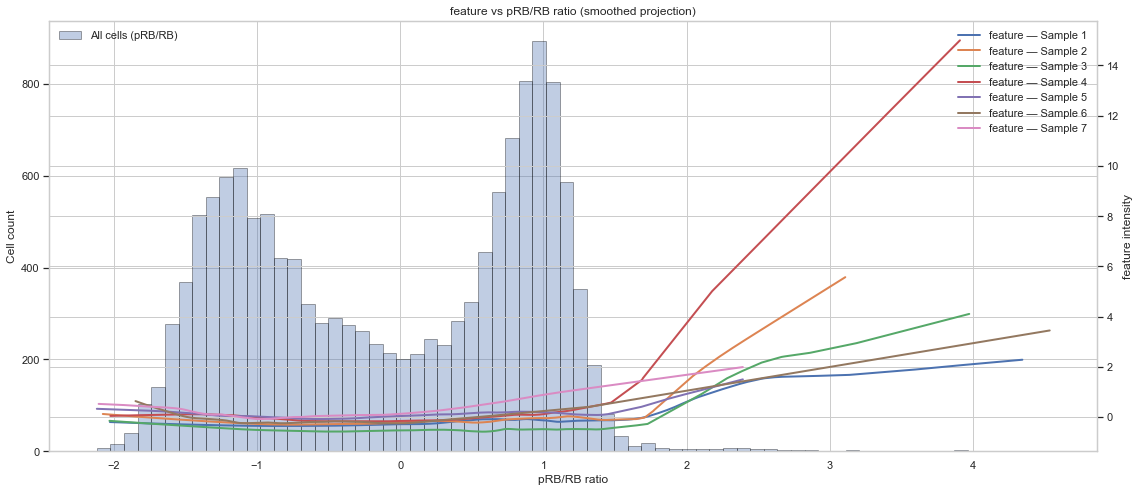

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from statsmodels.nonparametric.smoothers_lowess import lowess

# -------------------------
# CONFIG
# -------------------------
SAMPLE_COL = "sample_ID"
PRB_COL = "pRb_Rb_ratio"
FEATURE = "R2_Mdm2_ring_mean"

SAMPLE_IDS = sorted(adata.obs[SAMPLE_COL].unique())
BINS = 70
FIGSIZE = (16, 7)

# -------------------------
# GET MDM2 FROM X
# -------------------------
idx = np.where(adata.var_names == FEATURE)[0][0]

if sparse.issparse(adata.X):
    mdm2 = adata.X[:, idx].toarray().ravel()
else:
    mdm2 = np.asarray(adata.X[:, idx]).ravel()

adata.obs["mdm2"] = mdm2

# -------------------------
# GLOBAL HISTOGRAM (pRB/RB)
# -------------------------
x_all = adata.obs[PRB_COL].astype(float).values
counts, edges = np.histogram(x_all, bins=BINS)

centers = 0.5 * (edges[:-1] + edges[1:])
widths = edges[1:] - edges[:-1]

# -------------------------
# PLOT
# -------------------------
sns.set(style="whitegrid")
fig, ax1 = plt.subplots(figsize=FIGSIZE)

ax1.bar(
    centers,
    counts,
    width=widths,
    alpha=0.35,
    edgecolor="black",
    label="All cells (pRB/RB)"
)

ax1.set_xlabel("pRB/RB ratio")
ax1.set_ylabel("Cell count")

ax2 = ax1.twinx()

# -------------------------
# SMOOTHED PROJECTION PER SAMPLE
# -------------------------
for sid in SAMPLE_IDS:

    sub = adata.obs[adata.obs[SAMPLE_COL] == sid]

    x = sub[PRB_COL].astype(float).values
    y = sub["mdm2"].astype(float).values

    if len(x) < 20:
        continue

    # sort for smooth curve
    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    # LOWESS smoothing (THIS fixes the “broken line”)
    smooth = lowess(y_sorted, x_sorted, frac=0.25, return_sorted=True)

    ax2.plot(
        smooth[:, 0],
        smooth[:, 1],
        linewidth=2,
        label=f"feature — Sample {sid}"
    )

# -------------------------
# FINAL FORMATTING
# -------------------------
ax1.set_title("feature vs pRB/RB ratio (smoothed projection)")

ax2.set_ylabel("feature intensity")

ax1.legend(loc="upper left", frameon=False)
ax2.legend(loc="upper right", frameon=False)

plt.tight_layout()
plt.show()

In [4]:
# global z-score
vals = adata.obs[FEATURE_COL].astype(float).dropna().values
mean, std = vals.mean(), vals.std()
adata.obs[f"{FEATURE_COL}_z"] = (adata.obs[FEATURE_COL].astype(float) - mean) / std
print(f"Global z-score: mean={mean:.4f}, std={std:.4f}")

KeyError: 'R2_Mdm2_nuc_mean'

In [9]:
# style
sns.set(context="notebook", style="whitegrid")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

In [10]:
def format_dose(dose):
    s = str(dose).strip()
    return s if "nM" in s else f"{s} nM"

def slide_title(drug, dose, sample_id, n, bins):
    drug_title = str(drug).capitalize()
    return f"{drug_title} {format_dose(dose)} — Sample {sample_id} | N={n} | {bins} bins"


In [11]:
def make_histogram(adata, sample_id, bins=70, threshold_z=0.0):
    sub = adata.obs[adata.obs[SAMPLE_COL] == sample_id]
    if sub.empty:
        return None, None
    
    drug, dose = sub[DRUG_COL].iloc[0], sub[DOSE_COL].iloc[0]
    x = sub[f"{FEATURE_COL}_z"].dropna().values
    if x.size == 0:
        return None, None

    counts, edges = np.histogram(x, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths  = edges[1:] - edges[:-1]

    fig, ax = plt.subplots(figsize=(16,7))
    ax.bar(centers, counts, width=widths, align="center",
           alpha=0.85, edgecolor="black", linewidth=0.8)

    ymax = max(counts) * 1.15
    ax.set_ylim(0, ymax)

    for cx, cy in zip(centers, counts):
        if cy > 0:
            ax.text(cx, cy+(0.02*ymax), f"{cy:,}", ha="center",
                    va="bottom", fontsize=7, fontweight="bold", rotation=90)

    ax.set_xticks(edges)
    labels = ["0" if np.isclose(e,0,atol=1e-6) else f"{e:.2f}" for e in edges]
    ax.set_xticklabels(labels, rotation=65, ha="right", fontsize=8)

    ax.axvline(threshold_z, color="red", linestyle="--", linewidth=1.5)

    title = slide_title(drug, dose, sample_id, n=x.size, bins=bins)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(f"{FEATURE_COL} (z-scored globally)", fontsize=12)
    ax.set_ylabel("Cell count", fontsize=12)

    plt.tight_layout()
    plt.show()  # display in VS Code

    return fig, title


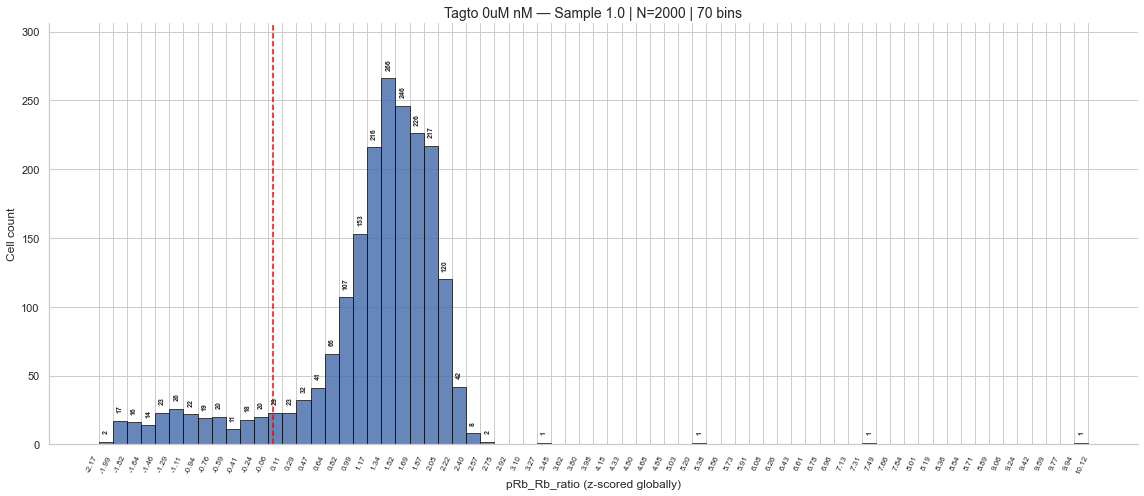

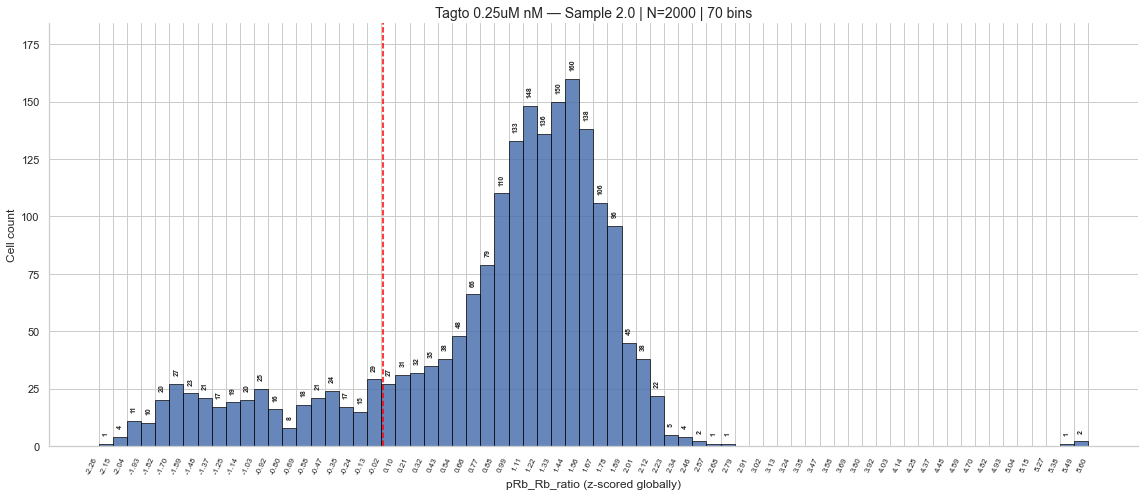

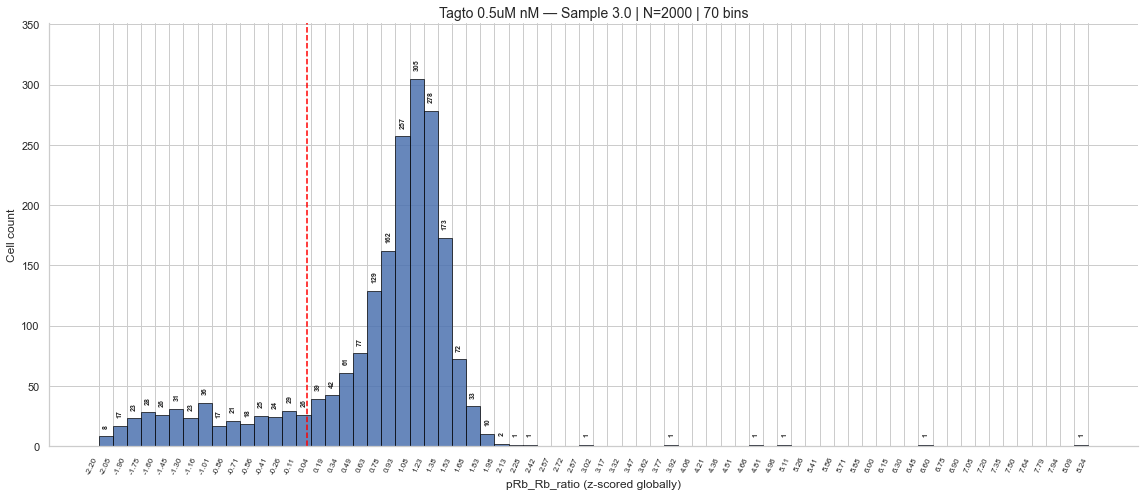

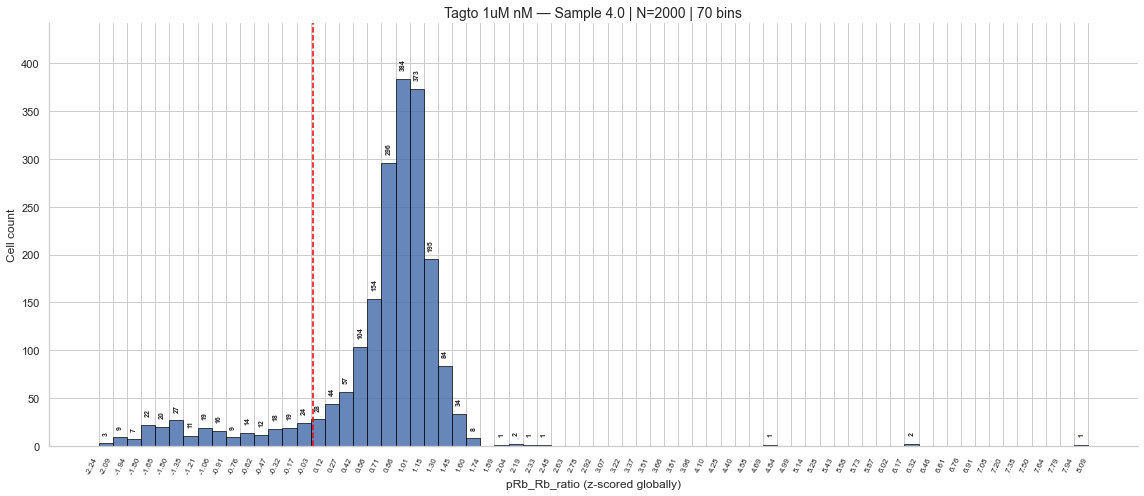

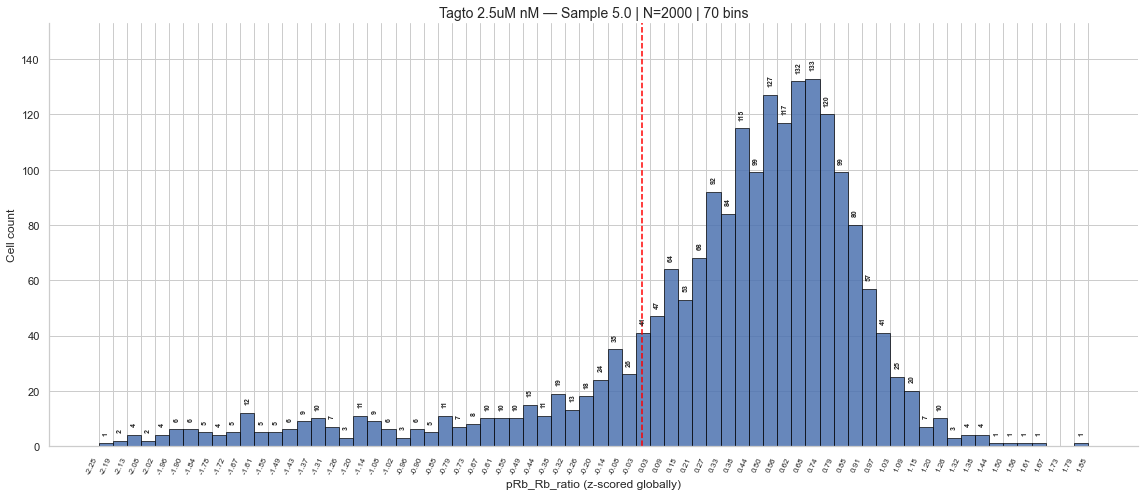

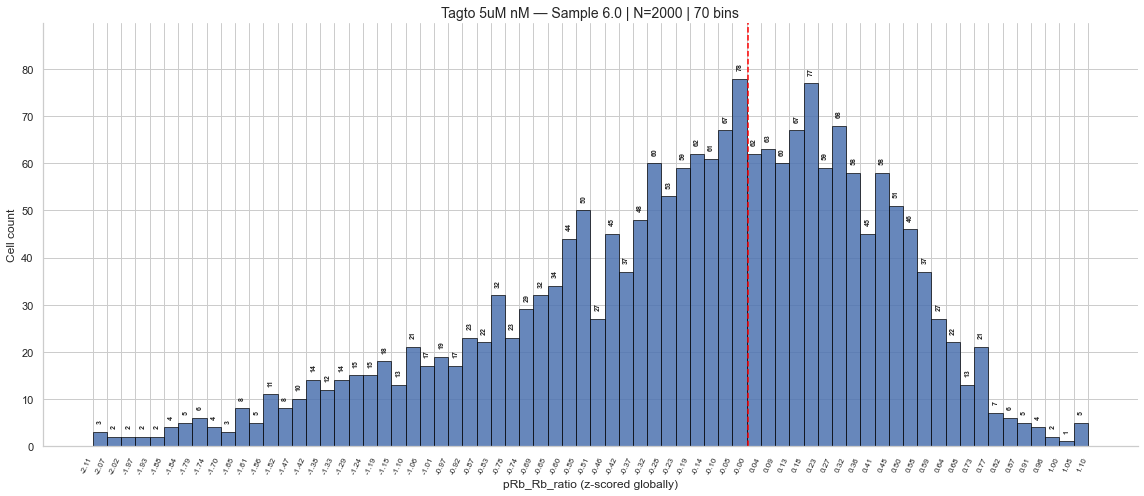

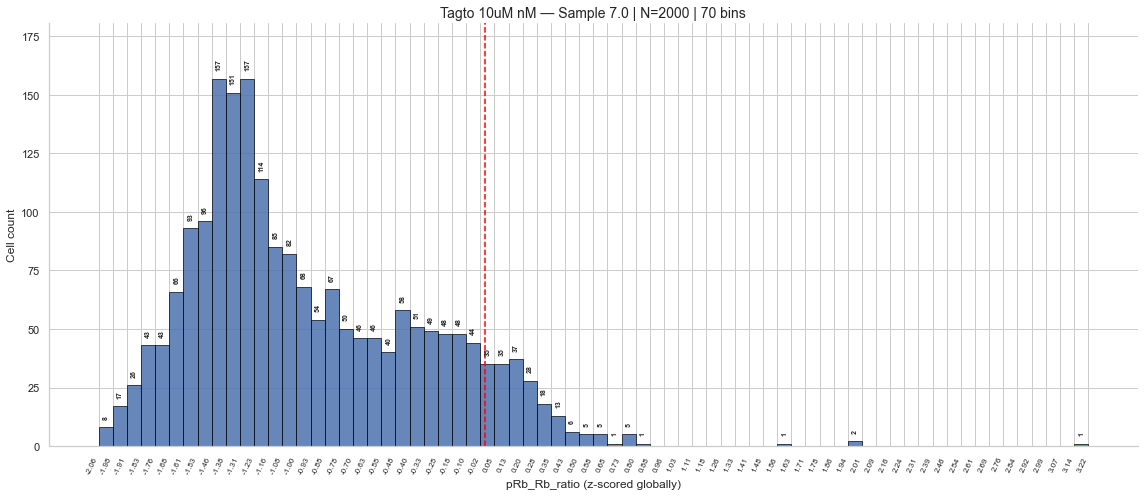

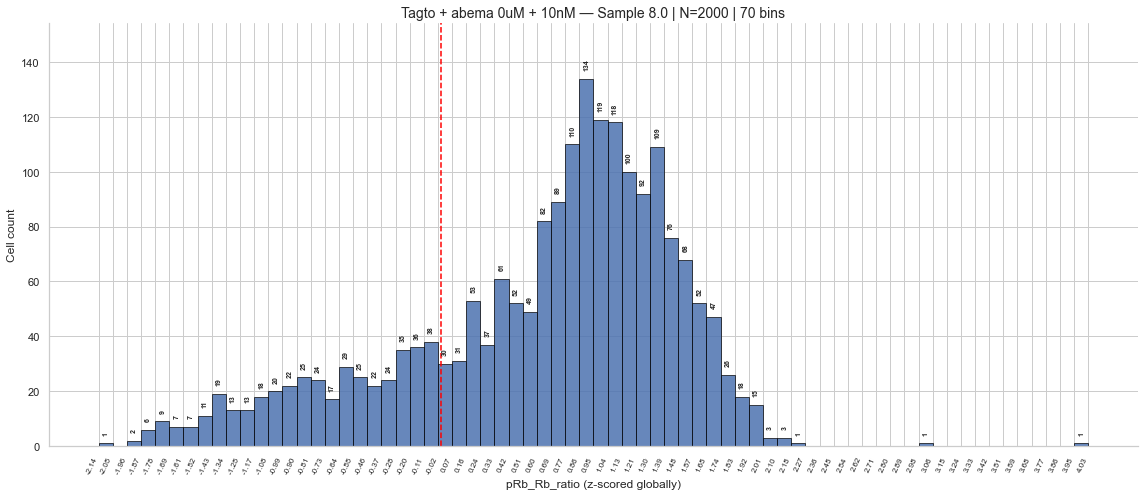

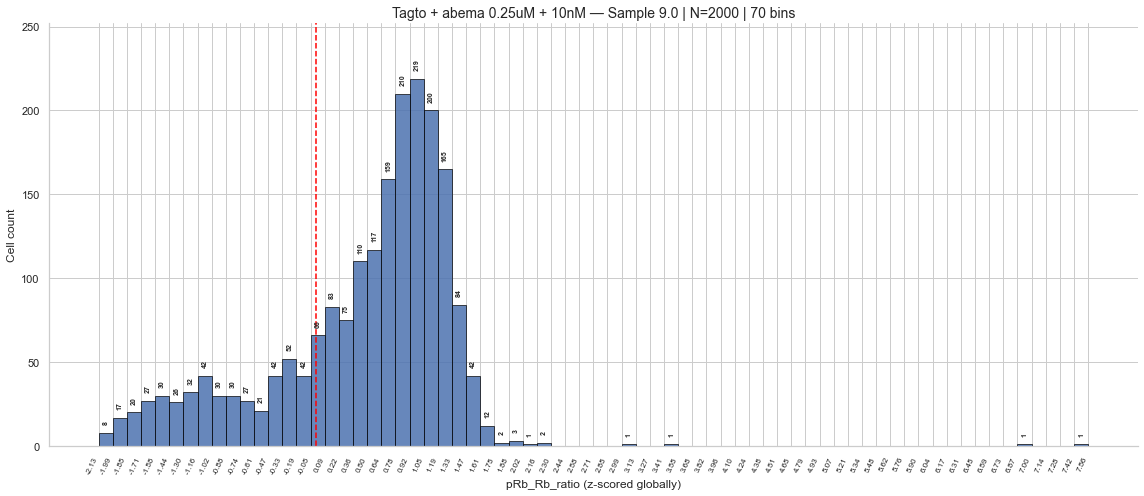

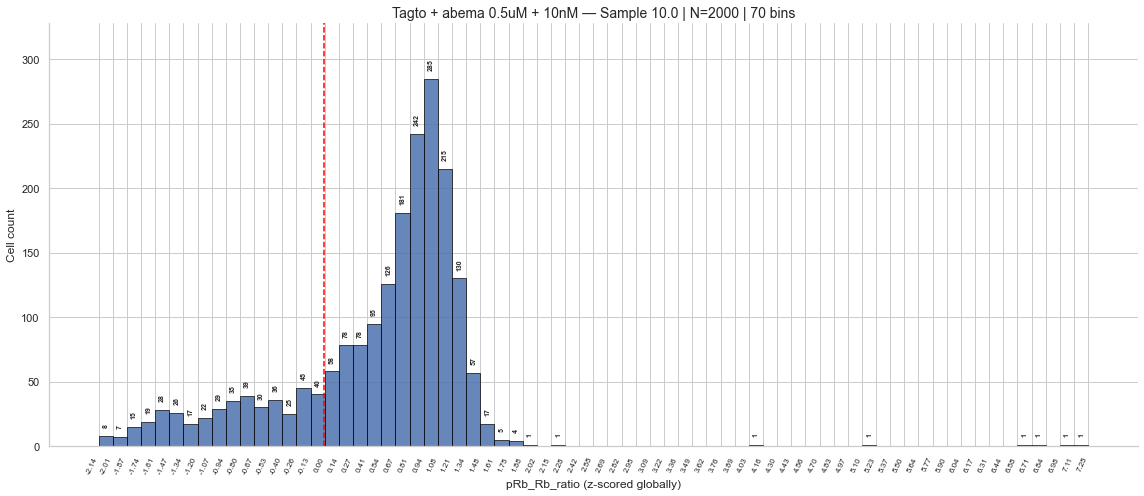

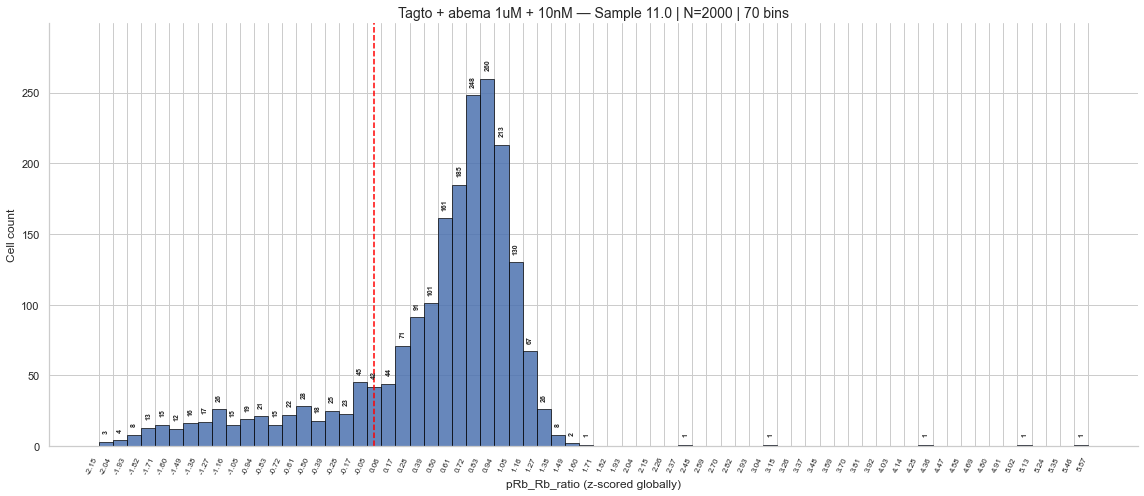

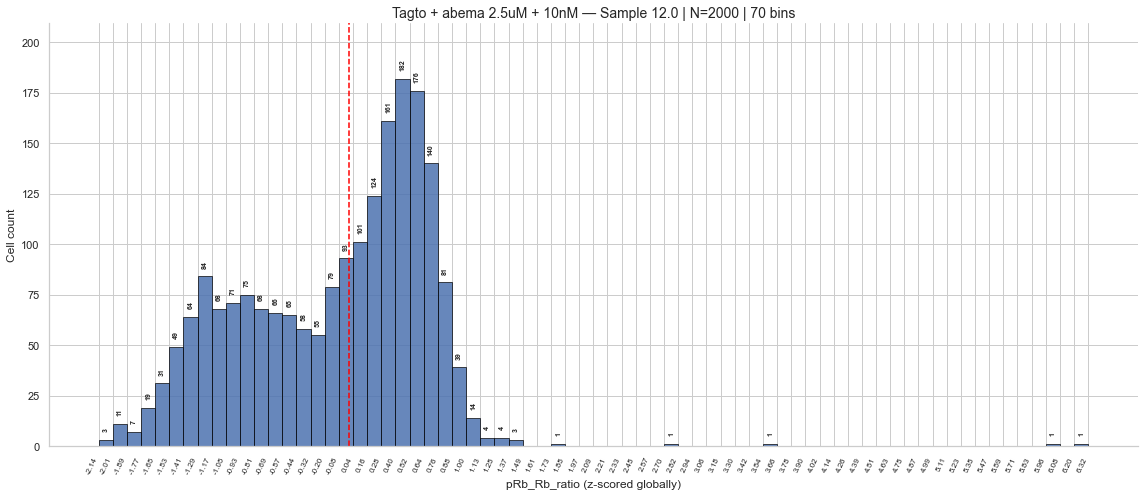

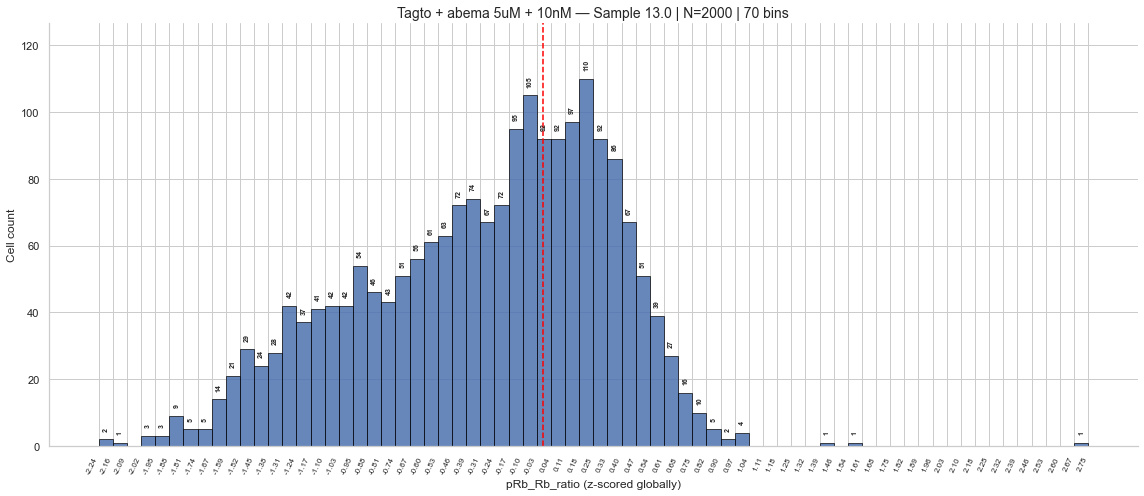

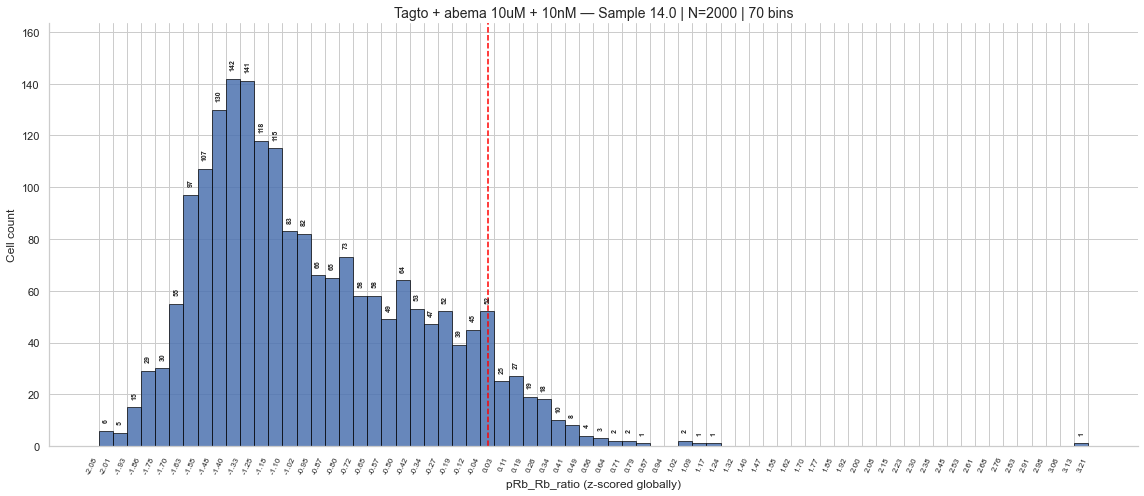

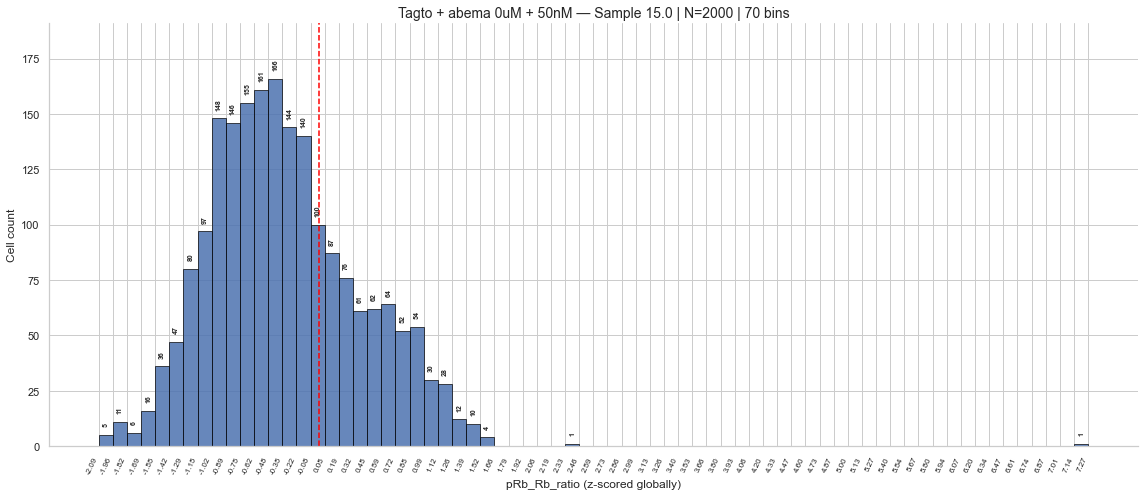

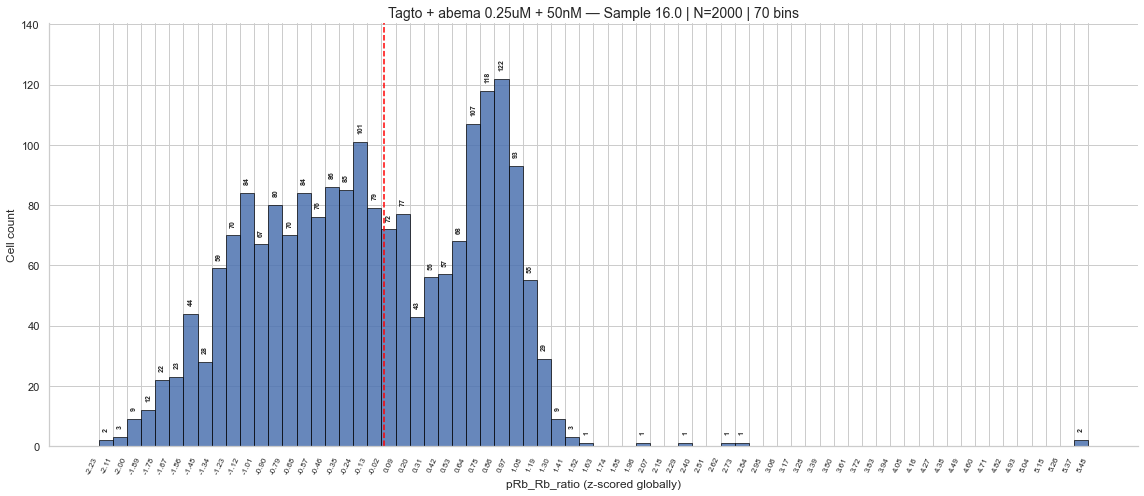

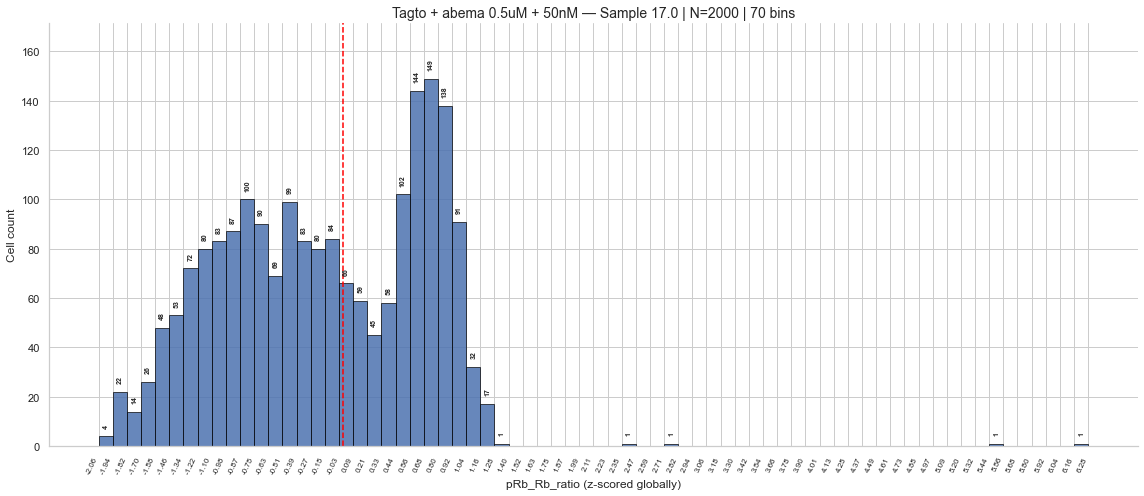

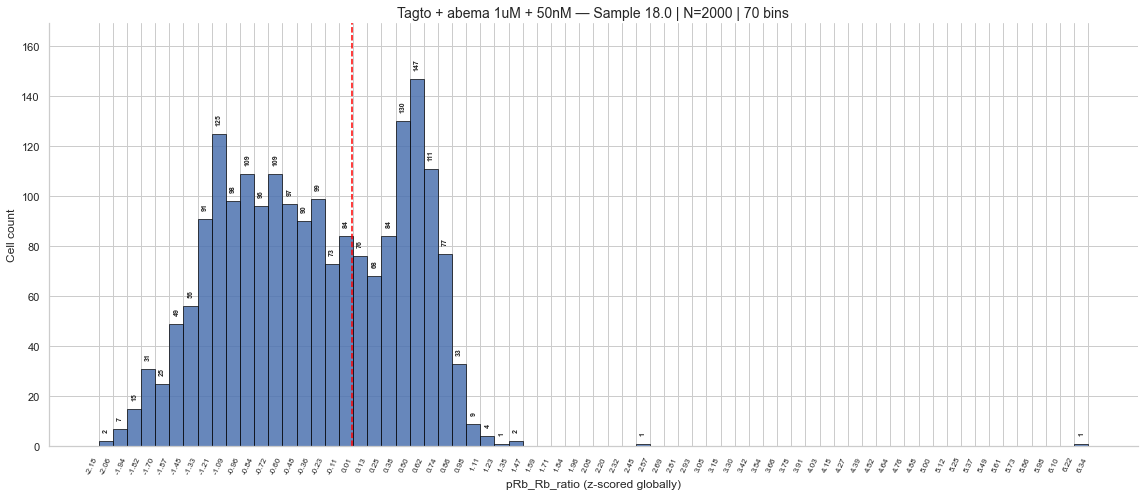

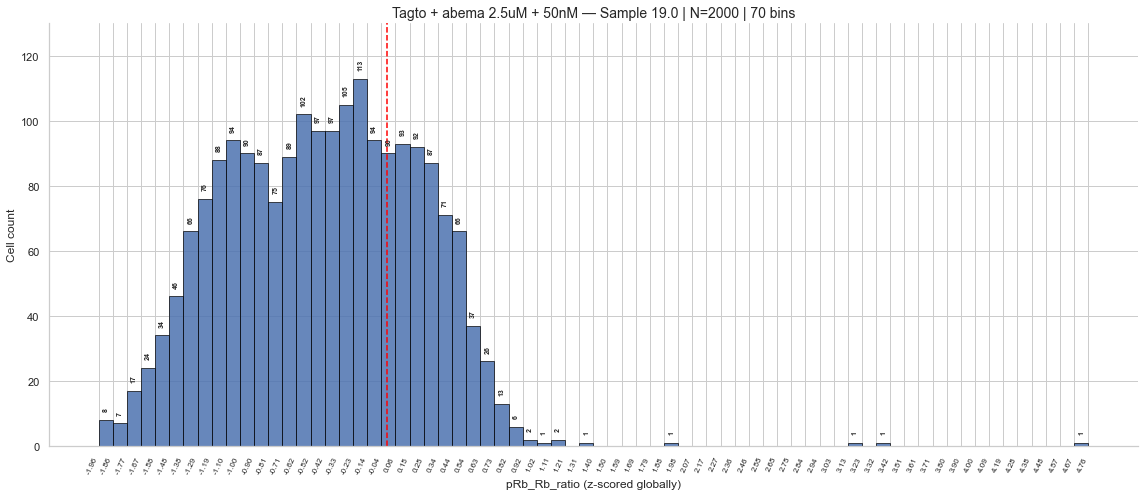

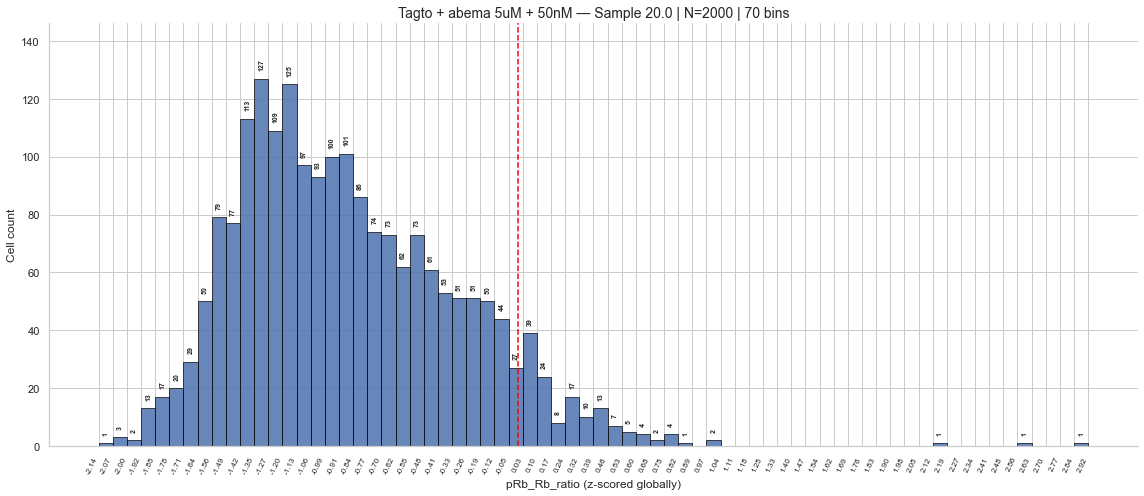

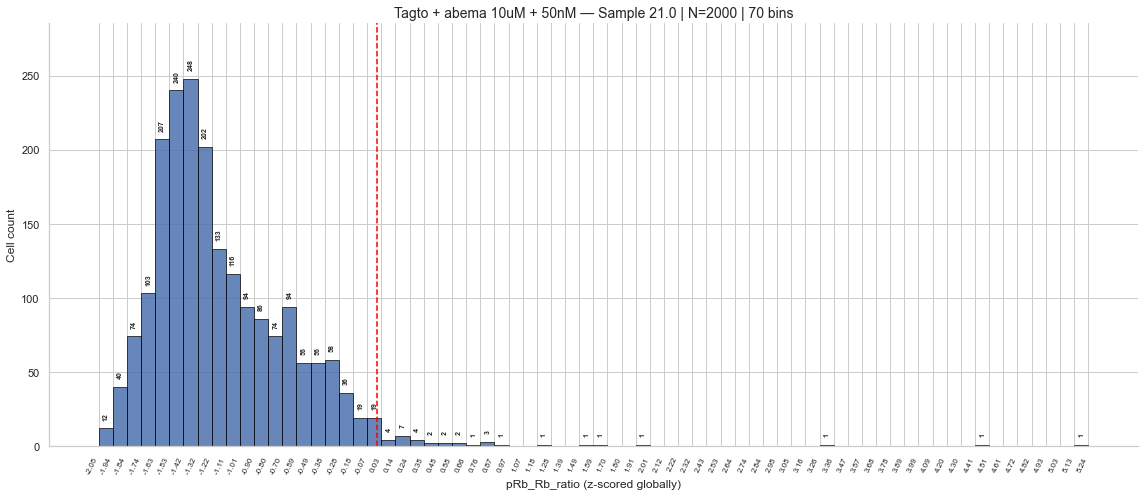

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Lauryn\\Liposarcoma_2026\\Replicate_LPS_246_Tagto_Abema_Co_Treat\\analysis_pipeline_pptx\\pRB_RB_histograms.pptx'

In [12]:
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_PARAGRAPH_ALIGNMENT
from PIL import Image
import os

# PowerPoint destination
PPTX_PATH = os.path.join(ROOT, "analysis_pipeline_pptx", "pRB_RB_histograms.pptx")

# Slide layout
prs = Presentation()
title_only = prs.slide_layouts[5]  # title only

LEFT_MARGIN   = Inches(0.5)
RIGHT_MARGIN  = Inches(0.5)
TOP_GAP_AFTER_TITLE = Inches(0.25)
BOTTOM_MARGIN = Inches(0.35)
TITLE_FONTSIZE_PT = 24

def add_slide_with_image(prs, title_text, fig, tmp_name):
    """Save fig as PNG, add to slide with title, scale to fit, then remove PNG."""
    # save fig
    fig.savefig(tmp_name, dpi=300)
    plt.close(fig)

    slide = prs.slides.add_slide(title_only)

    # --- Title settings ---
    title_shape = slide.shapes.title
    title_shape.text = title_text
    tf = title_shape.text_frame
    tf.word_wrap = True
    for p in tf.paragraphs:
        p.alignment = PP_PARAGRAPH_ALIGNMENT.CENTER
        for r in p.runs:
            r.font.size = Pt(TITLE_FONTSIZE_PT)

    # --- Compute image box ---
    slide_w, slide_h = prs.slide_width, prs.slide_height
    left = LEFT_MARGIN
    top  = title_shape.top + title_shape.height + TOP_GAP_AFTER_TITLE
    max_w = slide_w - LEFT_MARGIN - RIGHT_MARGIN
    max_h = slide_h - top - BOTTOM_MARGIN

    with Image.open(tmp_name) as im:
        img_w_px, img_h_px = im.size
    img_aspect = img_w_px / img_h_px
    box_aspect = max_w / max_h

    if img_aspect >= box_aspect:
        width = max_w
        height = int(width / img_aspect)
    else:
        height = max_h
        width = int(height * img_aspect)

    left_centered = left + (max_w - width) // 2

    slide.shapes.add_picture(tmp_name, left=left_centered, top=top,
                             width=width, height=height)

    os.remove(tmp_name)


# ---- regenerate histograms and build PPT ----
BINS = 70
THRESH_Z = 0.0
sample_ids = sorted(adata.obs[SAMPLE_COL].unique())

for sid in sample_ids:
    fig, title = make_histogram(adata, sid, bins=BINS, threshold_z=THRESH_Z)
    if fig is None:
        continue
    tmp_png = f"_tmp_hist_{sid}.png"
    add_slide_with_image(prs, title, fig, tmp_png)

prs.save(PPTX_PATH)
print(f"PowerPoint saved to: {PPTX_PATH}")


[zscore] total_DNA → total_DNA_z (mean=0.0353, std=1.0322, N=20,000)

Counts per sample (pRB_low / pRB_high):
_lab       pRB_high  pRB_low
sample_ID                   
1              1860      140
2              1826      174
3              1789      211
4              1636      364
5               862     1138
6               100     1900
7               117     1883


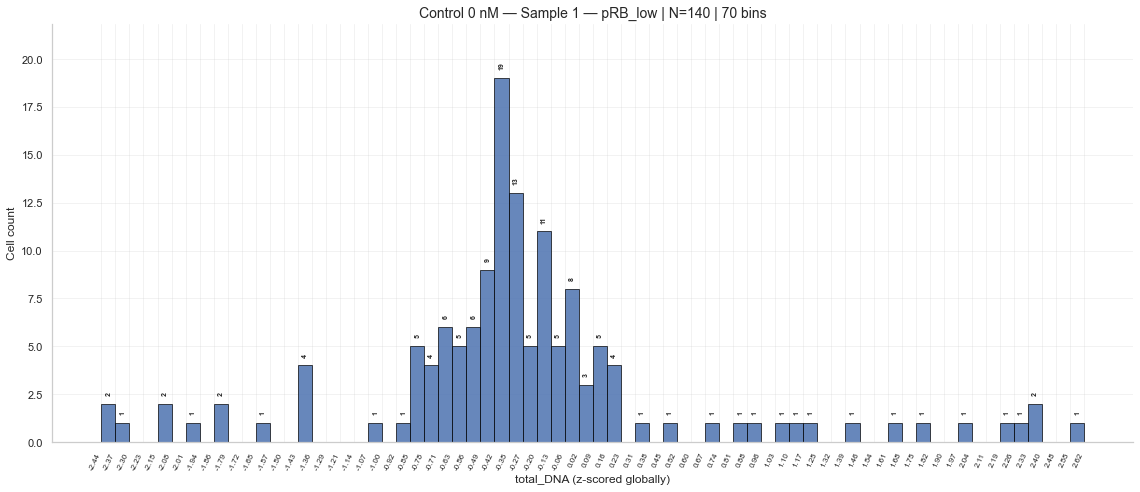

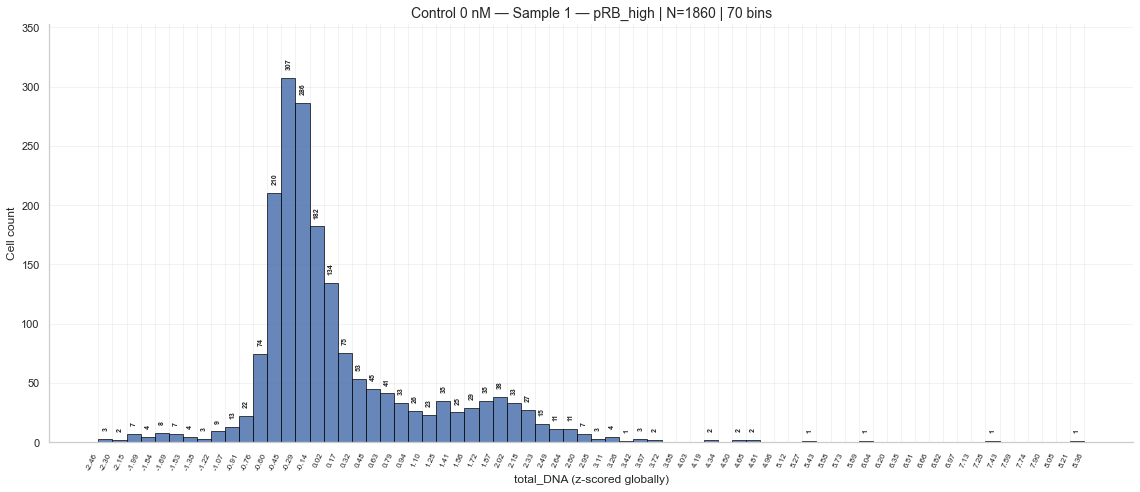

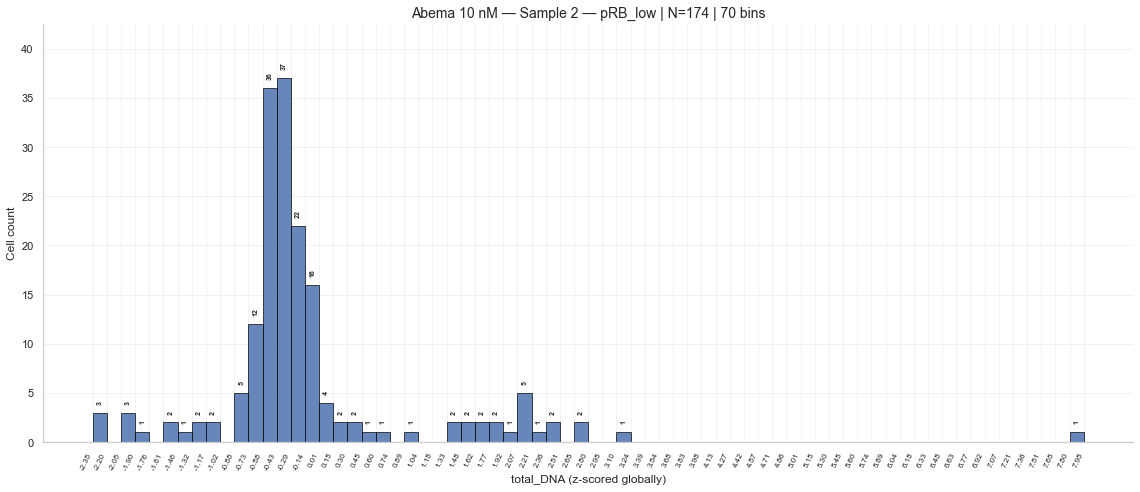

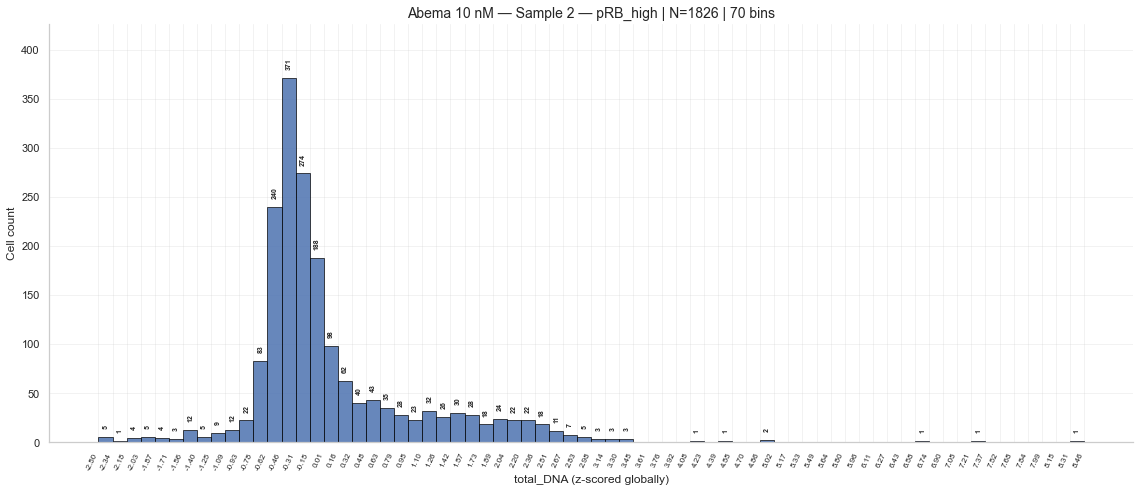

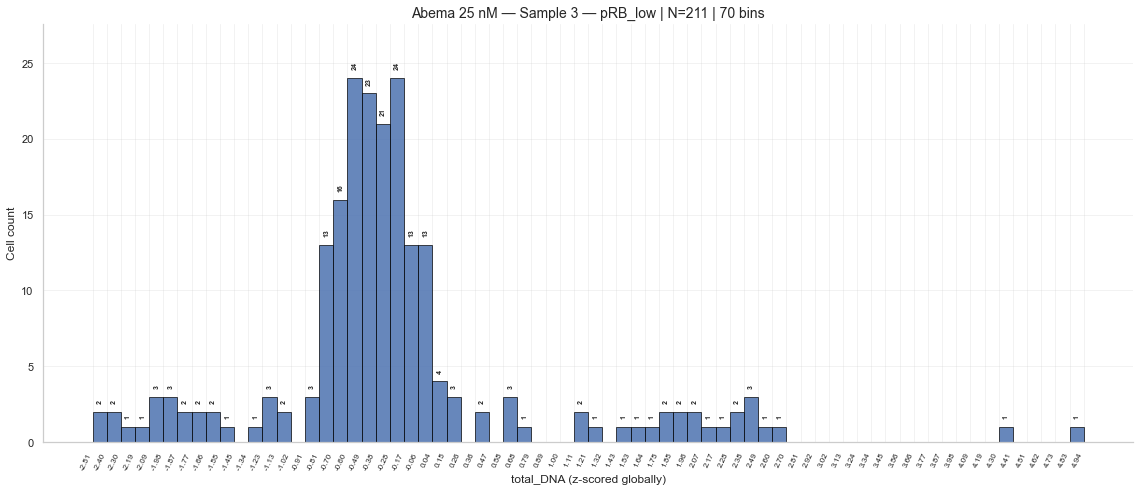

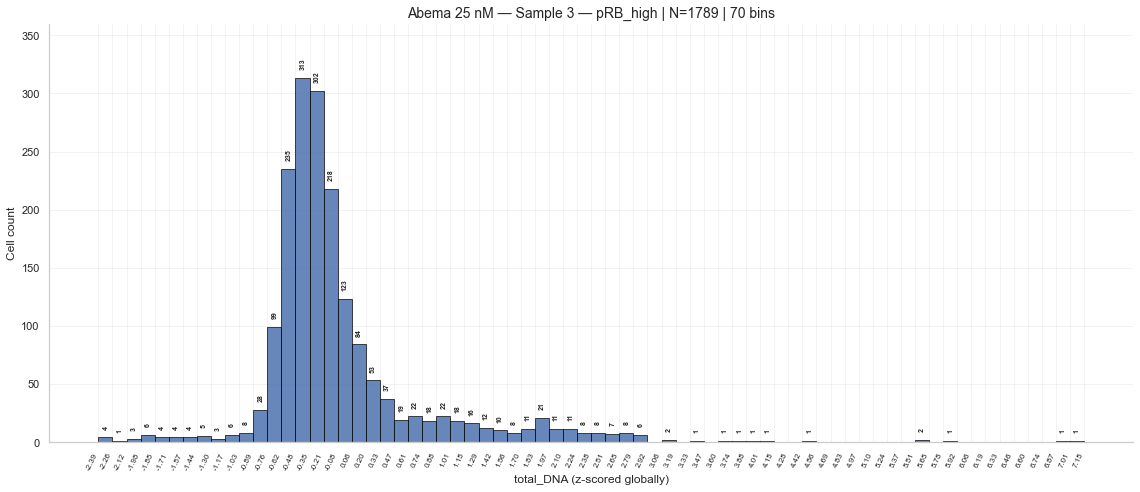

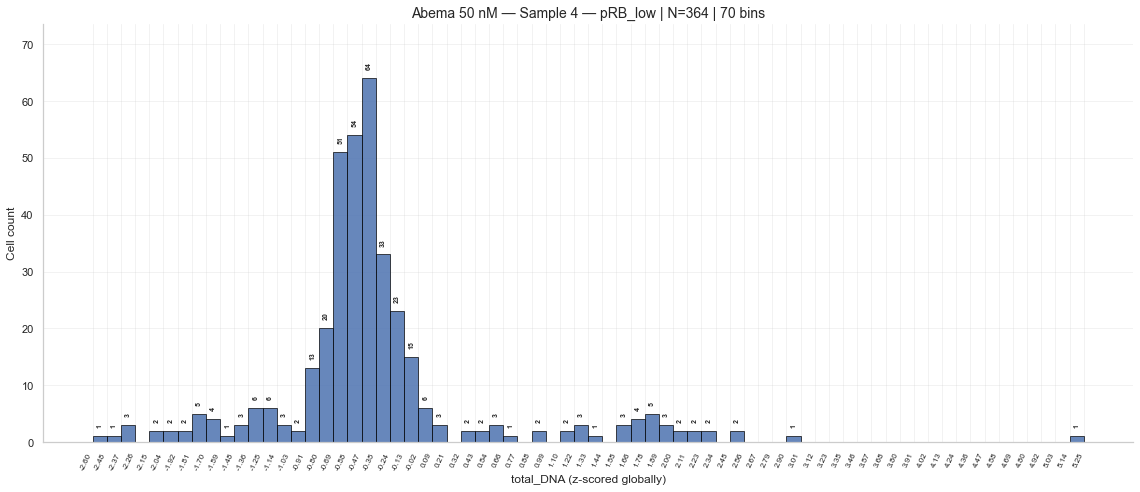

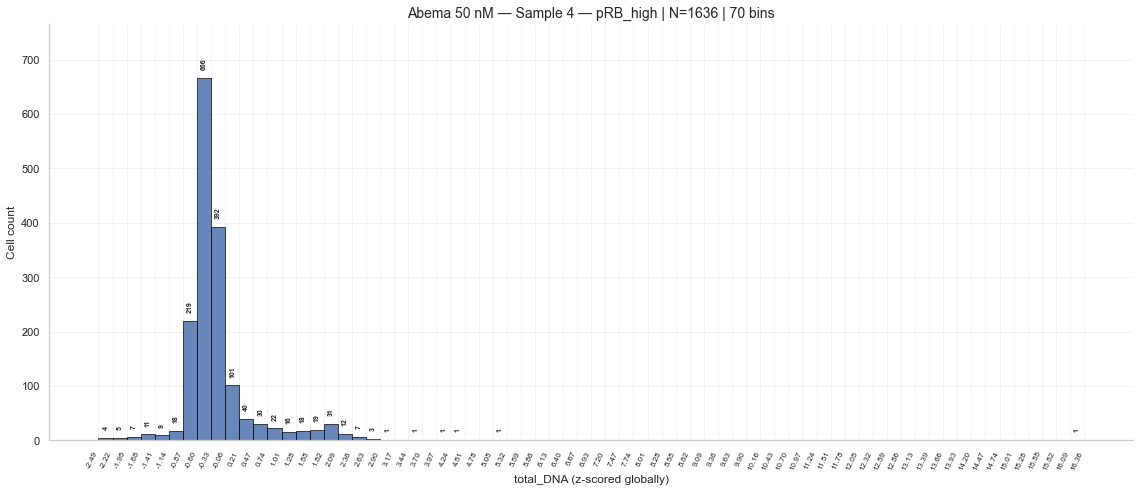

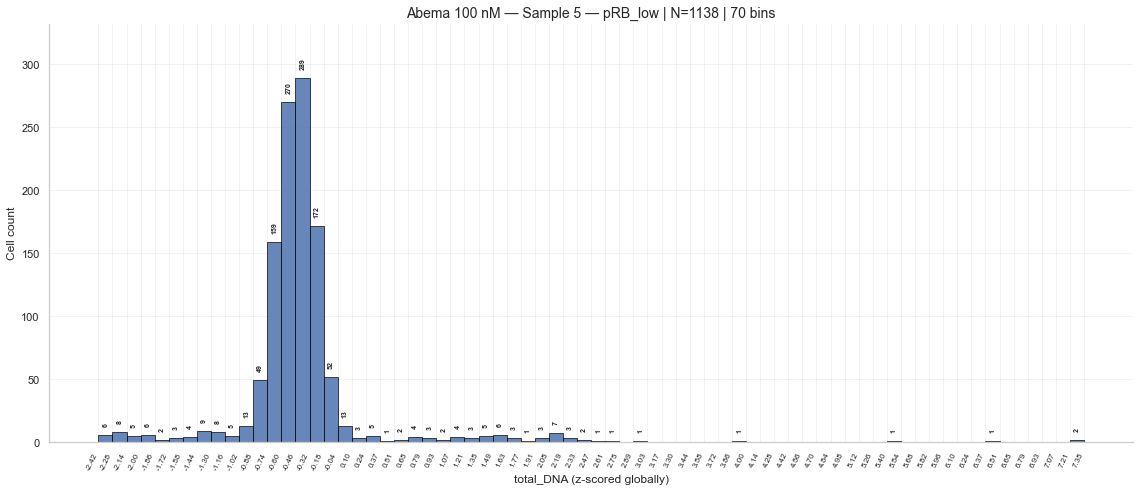

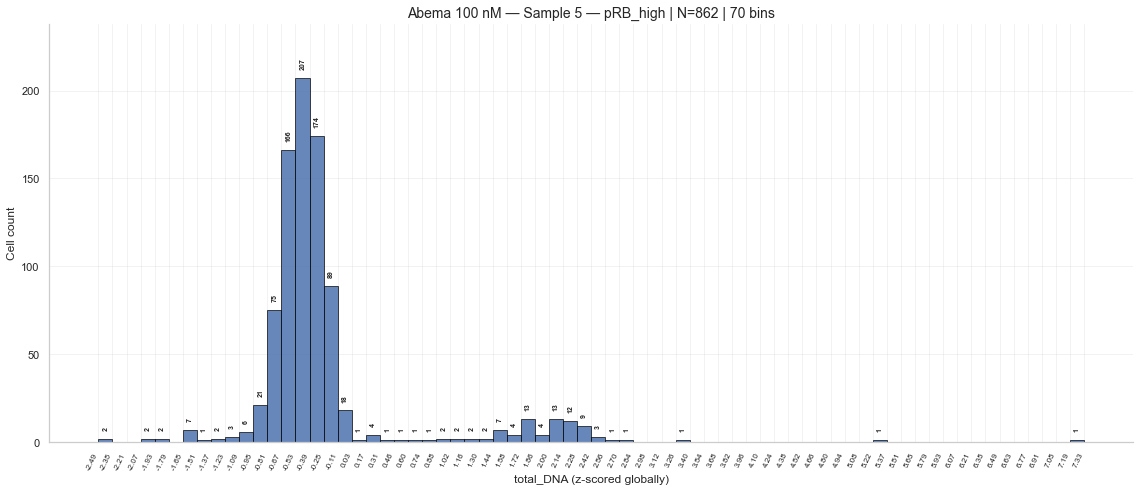

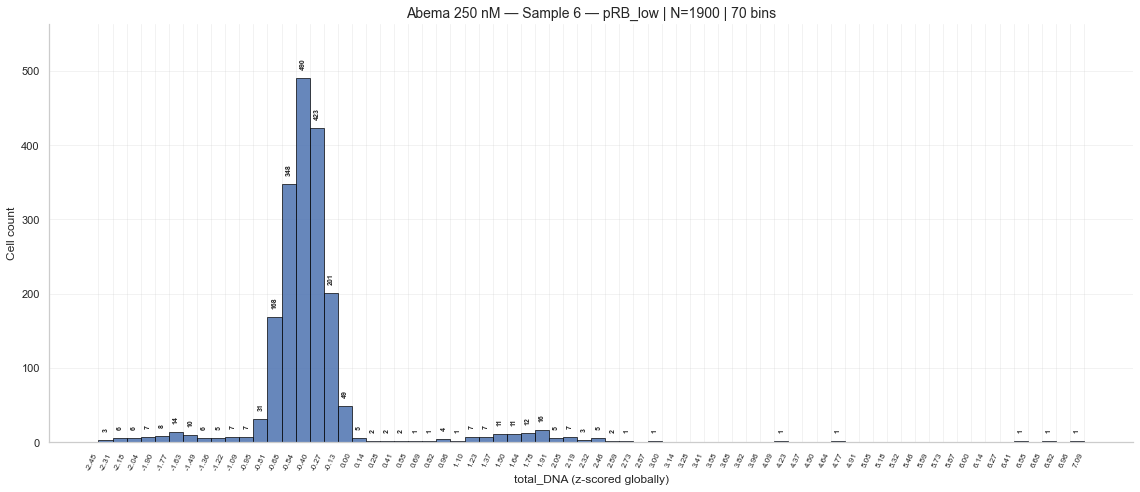

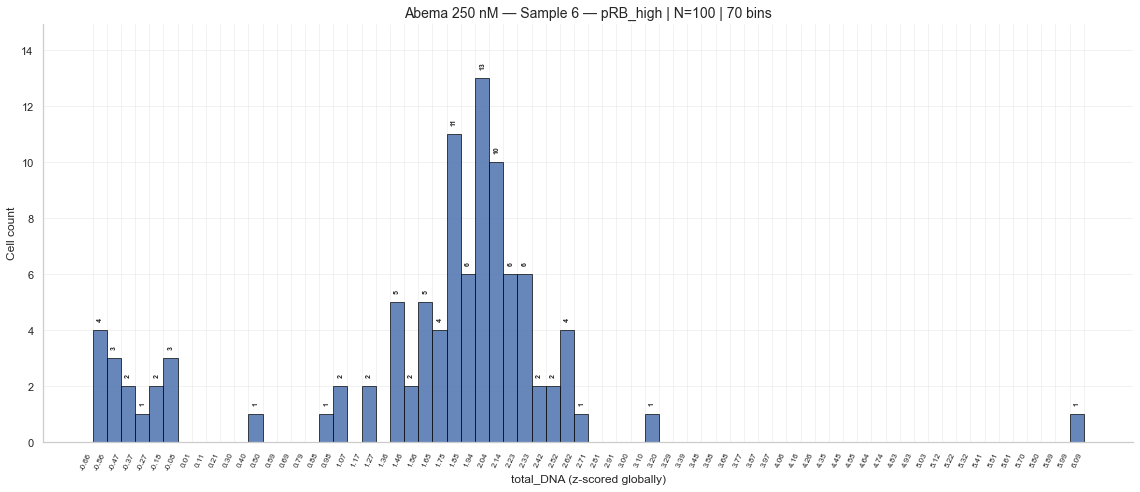

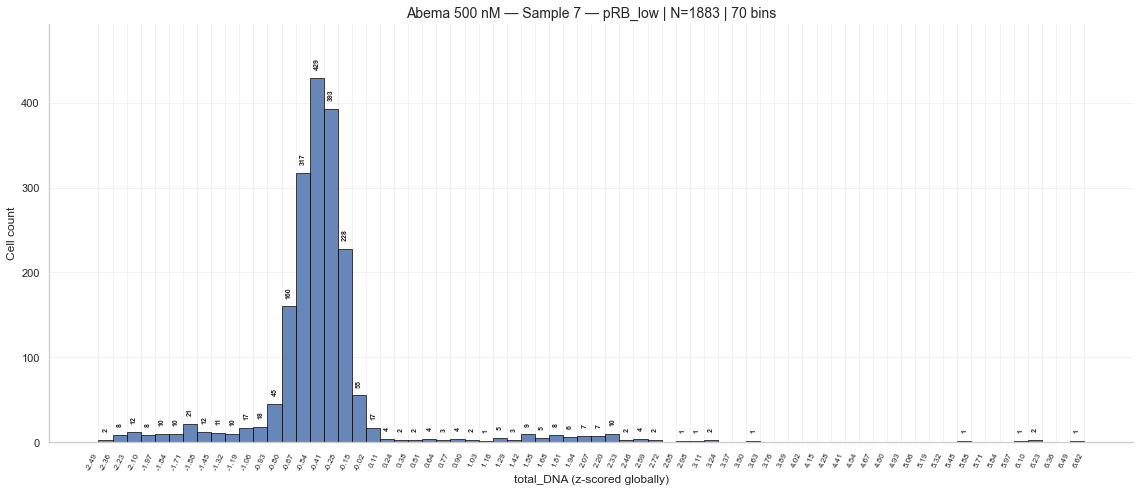

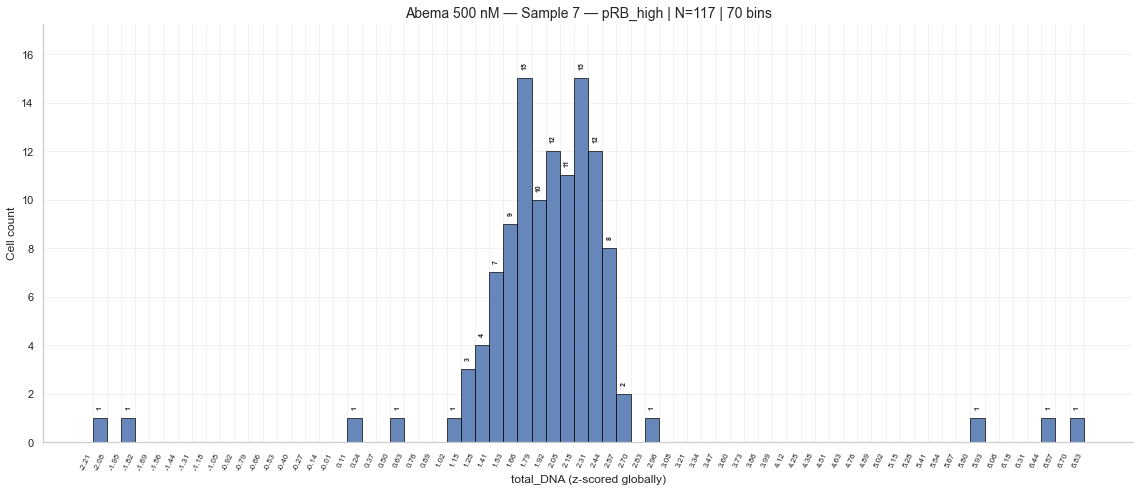

Done. Saved 14 slides to: D:\Sam\4i_Liposarcoma_Data_YR2025\LPS_246_Abema_July_2025\analysis_pipeline_pptx\TotalDNA_pRBsplit_histograms.pptx


In [52]:
# === 14 histograms from standard_adata_sub.h5ad: Total DNA per sample (1–7) × {pRB_low, pRB_high} ===
import os, re, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy import sparse
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_PARAGRAPH_ALIGNMENT
from PIL import Image
import pandas as pd

# If not already loaded:
# import scanpy as sc
# adata = sc.read_h5ad(r"D:\Sam\4i_Liposarcoma_Data_YR2025\LPS_246_Abema_July_2025\standard_adata_sub.h5ad")

ROOT = r"D:\Sam\4i_Liposarcoma_Data_YR2025\LPS_246_Abema_July_2025"
PPTX_PATH = os.path.join(ROOT, "analysis_pipeline_pptx", "TotalDNA_pRBsplit_histograms.pptx")

SAMPLE_IDS    = [1,2,3,4,5,6,7]
SAMPLE_COL    = "sample_ID"
DRUG_COL      = "treatment"
DOSE_COL      = "dose"
PRB_LABEL_COL = "pRB_label"     # your notebooks use this
DNA_OBS_COL   = "total_DNA"     # if absent, we’ll pull/compute from .var/.X
BINS, FIGSIZE = 70, (16, 7)

# --- helpers to pull from .var/.X if needed ---
def _find_var(name_like, varnames):
    # exact, ci, then flexible underscores
    for v in varnames:
        if str(v) == name_like: return str(v)
    for v in varnames:
        if str(v).lower() == name_like.lower(): return str(v)
    rx = re.compile(name_like.replace("_", ".*"), re.I)
    for v in varnames:
        if rx.search(str(v)): return str(v)
    return None

def _col_from_X(adata, var_name):
    j = int(np.where(adata.var_names == var_name)[0][0])
    X = adata.X
    if sparse.issparse(X):
        return X[:, j].toarray().ravel()
    return np.asarray(X[:, j]).ravel()

# --- ensure total_DNA is in .obs, using only this .h5ad ---
if DNA_OBS_COL not in adata.obs.columns or adata.obs[DNA_OBS_COL].isna().all():
    # 1) try feature named like total_DNA in var
    var_total = None
    for cand in ["total_DNA", "total_dna", "Total_DNA", "TotalDNA", "totalDNA"]:
        var_total = _find_var(cand, adata.var_names)
        if var_total: break

    if var_total:
        adata.obs[DNA_OBS_COL] = _col_from_X(adata, var_total).astype(float)
        print(f"[ok] Pulled {DNA_OBS_COL} from X via var '{var_total}'")
    else:
        # 2) compute exactly as in conversion: R0_DNA_nuc_mean * nuc_area
        r0_name   = _find_var("R0_DNA_nuc_mean", adata.var_names) or _find_var("R0DNA_nuc_mean", adata.var_names)
        area_name = _find_var("nuc_area", adata.var_names) or _find_var("nucleus_area", adata.var_names)
        if not (r0_name and area_name):
            raise KeyError("Could not find total_DNA in obs/var, nor R0_DNA_nuc_mean/nuc_area in var to compute it.")
        r0   = _col_from_X(adata, r0_name).astype(float)
        area = _col_from_X(adata, area_name).astype(float)
        adata.obs[DNA_OBS_COL] = r0 * area
        print(f"[ok] Computed {DNA_OBS_COL} from X: '{r0_name}' * '{area_name}'")

# --- z-score Total DNA globally (once) ---
vals = adata.obs[DNA_OBS_COL].astype(float).dropna().values
dna_mean, dna_std = vals.mean(), vals.std()
adata.obs["total_DNA_z"] = (adata.obs[DNA_OBS_COL].astype(float) - dna_mean) / dna_std
print(f"[zscore] {DNA_OBS_COL} → total_DNA_z (mean={dna_mean:.4f}, std={dna_std:.4f}, N={vals.size:,})")

# --- normalize pRB labels to the exact forms you use in the notebooks ---
def _norm_prb(series):
    s = series.astype(str).str.strip().str.lower()
    out = []
    for v in s:
        if v in {"prb_high","pRB_high".lower(),"high","1","true","t","yes","y","h"} or "prb_high" in v or "pRB_high".lower() in v or "high" in v:
            out.append("pRB_high")
        elif v in {"prb_low","pRB_low".lower(),"low","0","false","f","no","n","l"} or "prb_low" in v or "pRB_low".lower() in v or "low" in v:
            out.append("pRB_low")
        else:
            out.append(v)
    return pd.Series(out, index=series.index)

adata.obs["_pRB_label_norm"] = _norm_prb(adata.obs[PRB_LABEL_COL])

# quick sanity table (optional)
counts = (adata.obs
          .assign(_lab=adata.obs["_pRB_label_norm"])
          .groupby([SAMPLE_COL, "_lab"]).size().unstack(fill_value=0)
          .reindex(SAMPLE_IDS, fill_value=0))
print("\nCounts per sample (pRB_low / pRB_high):")
print(counts)

# --- plotting style + helpers ---
sns.set(context="notebook", style="whitegrid")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})

def _format_dose(dose):
    s = str(dose).strip()
    return s if re.search(r"\bnm\b", s, re.I) else f"{s} nM"

def _title(drug, dose, sid, label, n):
    drug_t = drug if str(drug).isupper() else str(drug).capitalize()
    return f"{drug_t} {_format_dose(dose)} — Sample {sid} — {label} | N={n} | {BINS} bins"

def _hist(x, title):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    if x.size:
        counts, edges = np.histogram(x, bins=BINS)
        centers = 0.5*(edges[:-1]+edges[1:]); widths = edges[1:] - edges[:-1]
        ax.bar(centers, counts, width=widths, align="center", alpha=0.85, edgecolor="black", linewidth=0.8)
        ymax = max(counts) * 1.15
        ax.set_ylim(0, ymax)
        for cx, cy in zip(centers, counts):
            if cy>0: ax.text(cx, cy+(0.02*ymax), f"{cy:,}", ha="center", va="bottom", fontsize=7, fontweight="bold", rotation=90)
        ax.set_xticks(edges)
        ax.set_xticklabels([("0" if np.isclose(e,0,1e-6) else f"{e:.2f}") for e in edges], rotation=65, ha="right", fontsize=8)
        ax.set_ylabel("Cell count", fontsize=12)
    else:
        ax.text(0.5, 0.5, "No cells in this subset", ha="center", va="center", fontsize=14)
        ax.set_xticks([]); ax.set_yticks([]); [sp.set_visible(False) for sp in ax.spines.values()]
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("total_DNA (z-scored globally)", fontsize=12)
    plt.tight_layout(); plt.show()
    return fig

# --- PowerPoint helper (no overlap) ---
TITLE_FONTSIZE_PT = 24
LEFT_MARGIN, RIGHT_MARGIN = Inches(0.5), Inches(0.5)
TOP_GAP_AFTER_TITLE, BOTTOM_MARGIN = Inches(0.25), Inches(0.35)

def _add_slide(prs, title_text, fig, tmp_png):
    fig.savefig(tmp_png, dpi=300); plt.close(fig)
    slide = prs.slides.add_slide(prs.slide_layouts[5])  # title-only
    t = slide.shapes.title; t.text = title_text
    tf = t.text_frame; tf.word_wrap = True
    for p in tf.paragraphs:
        p.alignment = PP_PARAGRAPH_ALIGNMENT.CENTER
        for r in p.runs: r.font.size = Pt(TITLE_FONTSIZE_PT)
    sw, sh = prs.slide_width, prs.slide_height
    left = LEFT_MARGIN
    top  = t.top + t.height + TOP_GAP_AFTER_TITLE
    max_w, max_h = sw - LEFT_MARGIN - RIGHT_MARGIN, sh - top - BOTTOM_MARGIN
    with Image.open(tmp_png) as im: wpx, hpx = im.size
    aspect = wpx / hpx; box_aspect = max_w / max_h
    if aspect >= box_aspect: width, height = max_w, int(max_w / aspect)
    else: height, width = max_h, int(max_h * aspect)
    left_centered = left + (max_w - width)//2
    slide.shapes.add_picture(tmp_png, left=left_centered, top=top, width=width, height=height)
    os.remove(tmp_png)

# --- build exactly 14 histograms: IDs 1–7 × {pRB_low, pRB_high} ---
prs, made = Presentation(), 0
for sid in SAMPLE_IDS:
    sub = adata.obs[adata.obs[SAMPLE_COL] == sid]
    if sub.empty:
        # still add placeholders to keep 14 slides if a sample is absent
        for label in ["pRB_low", "pRB_high"]:
            title = f"Sample {sid} — {label} | N=0 | {BINS} bins"
            fig = _hist(np.array([]), title)
            _add_slide(prs, title, fig, f"_tmp_totalDNA_s{sid}_{label}.png")
            made += 1
        continue

    drug, dose = sub[DRUG_COL].iloc[0], sub[DOSE_COL].iloc[0]
    for label in ["pRB_low", "pRB_high"]:
        mask = (adata.obs[SAMPLE_COL]==sid) & (adata.obs["_pRB_label_norm"]==label)
        x = adata.obs.loc[mask, "total_DNA_z"].dropna().values
        title = _title(drug, dose, sid, label, n=x.size)
        fig = _hist(x, title)
        _add_slide(prs, title, fig, f"_tmp_totalDNA_s{sid}_{label}.png")
        made += 1

prs.save(PPTX_PATH)
print(f"Done. Saved {made} slides to: {PPTX_PATH}")


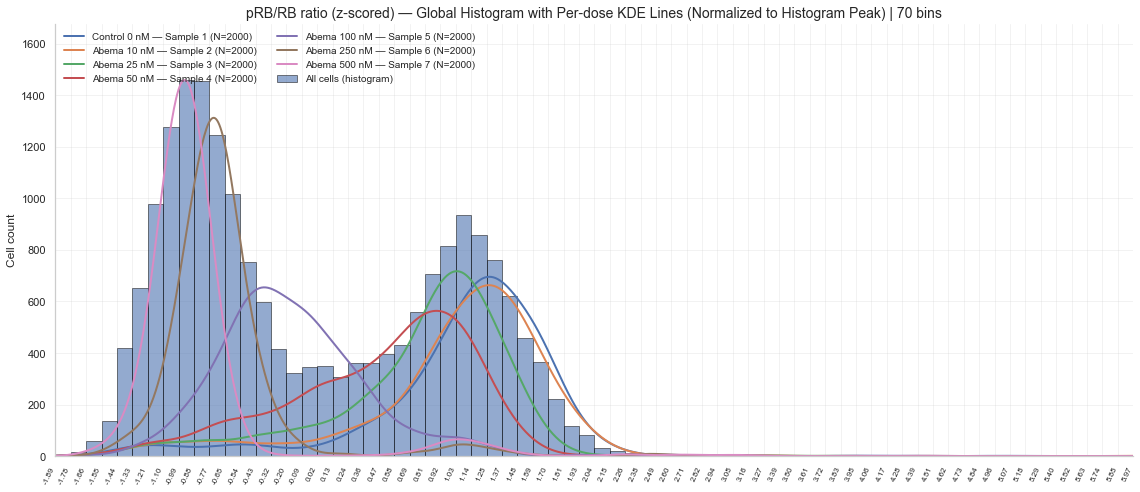

Saved PowerPoint: D:\Sam\4i_Liposarcoma_Data_YR2025\LPS_246_Abema_July_2025\analysis_pipeline_pptx\pRB_RB_ratio_all_with_dose_lines_NORMALIZED.pptx


In [55]:
# === Global pRB/RB histogram with per-dose KDE lines normalized to the histogram peak ===
import os, re, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import gaussian_kde
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_PARAGRAPH_ALIGNMENT
from PIL import Image
import pandas as pd

ROOT = r"D:\Sam\4i_Liposarcoma_Data_YR2025\LPS_246_Abema_July_2025"
PPTX_PATH = os.path.join(ROOT, "analysis_pipeline_pptx", "pRB_RB_ratio_all_with_dose_lines_NORMALIZED.pptx")

SAMPLE_IDS  = [1,2,3,4,5,6,7]
SAMPLE_COL  = "sample_ID"
DRUG_COL    = "treatment"
DOSE_COL    = "dose"

FEATURE_CANDIDATES = ["pRB_rB_ratio_z", "pRB_RB_ratio_z", "pRB_rB_ratio", "pRB_RB_ratio"]
feat = next((c for c in FEATURE_CANDIDATES if c in adata.obs.columns), None)
if feat is None:
    raise KeyError("Couldn't find pRB/RB ratio column in adata.obs. Looked for: " + ", ".join(FEATURE_CANDIDATES))

# z-score if needed
if not feat.endswith("_z"):
    vals = adata.obs[feat].astype(float).dropna().values
    mean, std = vals.mean(), vals.std()
    zcol = feat + "_z"
    adata.obs[zcol] = (adata.obs[feat].astype(float) - mean) / std
    feat = zcol
    print(f"[zscore] {feat} computed from raw pRB/RB ratio (global mean={mean:.4f}, std={std:.4f})")

sns.set(context="notebook", style="whitegrid")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})

BINS    = 70
FIGSIZE = (16, 7)

x_all = adata.obs[feat].astype(float).dropna().values
counts, edges = np.histogram(x_all, bins=BINS)
centers = 0.5*(edges[:-1] + edges[1:])
widths  = edges[1:] - edges[:-1]
bin_width = np.mean(widths)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(centers, counts, width=widths, align="center",
       alpha=0.6, edgecolor="black", linewidth=0.8, label="All cells (histogram)")

# ---- KDE lines for each dose, then normalize all lines to histogram peak ----
color_cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", None)
xgrid = np.linspace(edges[0], edges[-1], 1000)
kde_lines = []   # (xgrid, y_raw, label, color)

for i, sid in enumerate(SAMPLE_IDS):
    sub = adata.obs[adata.obs[SAMPLE_COL] == sid]
    if sub.empty: 
        continue
    drug = sub[DRUG_COL].iloc[0]
    dose = sub[DOSE_COL].iloc[0]
    dose_label = str(dose).strip()
    if not re.search(r"\bnm\b", dose_label, re.I):
        dose_label = f"{dose_label} nM"

    x = sub[feat].astype(float).dropna().values
    if x.size < 2:
        continue

    kde = gaussian_kde(x)
    # convert density to "expected counts per bin" for this subset
    y_raw = kde(xgrid) * x.size * bin_width
    color = color_cycle[i % len(color_cycle)] if color_cycle else None
    label = f"{drug} {dose_label} — Sample {sid} (N={x.size})"
    kde_lines.append((xgrid, y_raw, label, color))

# compute a single multiplier so tallest KDE peak ≈ tallest histogram bar
if kde_lines:
    max_hist_peak = counts.max()
    max_kde_peak  = max(float(y_raw.max()) for _, y_raw, _, _ in kde_lines)
    scale = (max_hist_peak / max_kde_peak) if max_kde_peak > 0 else 1.0
else:
    scale = 1.0

for xg, y_raw, label, color in kde_lines:
    ax.plot(xg, y_raw * scale, label=label, linewidth=2, color=color)

# cosmetics
ax.set_xlim(edges[0], edges[-1])
ymax = max(max(counts)*1.15, ax.get_ylim()[1])
ax.set_ylim(0, ymax)
ax.set_xticks(edges)
ax.set_xticklabels([("0" if np.isclose(e,0,1e-6) else f"{e:.2f}") for e in edges],
                   rotation=65, ha="right", fontsize=8)
ax.set_ylabel("Cell count", fontsize=12)
pretty_feat = "pRB/RB ratio (z-scored)"
title = f"{pretty_feat} — Global Histogram with Per-dose KDE Lines (Normalized to Histogram Peak) | {BINS} bins"
ax.set_title(title, fontsize=14)
ax.legend(frameon=False, fontsize=10, ncol=2, loc="upper left")

plt.tight_layout()
plt.show()

# ---- Save to PowerPoint (title + image, no overlap) ----
prs = Presentation()
title_only = prs.slide_layouts[5]
TITLE_FONTSIZE_PT = 24
LEFT_MARGIN, RIGHT_MARGIN = Inches(0.5), Inches(0.5)
TOP_GAP_AFTER_TITLE, BOTTOM_MARGIN = Inches(0.25), Inches(0.35)

def add_slide_with_image(prs, title_text, fig, tmp_name):
    fig.savefig(tmp_name, dpi=300)
    plt.close(fig)
    slide = prs.slides.add_slide(title_only)
    t = slide.shapes.title; t.text = title_text
    tf = t.text_frame; tf.word_wrap = True
    for p in tf.paragraphs:
        p.alignment = PP_PARAGRAPH_ALIGNMENT.CENTER
        for r in p.runs: r.font.size = Pt(TITLE_FONTSIZE_PT)
    sw, sh = prs.slide_width, prs.slide_height
    left = LEFT_MARGIN
    top  = t.top + t.height + TOP_GAP_AFTER_TITLE
    max_w, max_h = sw - LEFT_MARGIN - RIGHT_MARGIN, sh - top - BOTTOM_MARGIN
    with Image.open(tmp_name) as im: wpx, hpx = im.size
    aspect = wpx / hpx; box_aspect = max_w / max_h
    if aspect >= box_aspect: width, height = max_w, int(max_w / aspect)
    else: height, width = max_h, int(max_h * aspect)
    left_centered = left + (max_w - width)//2
    slide.shapes.add_picture(tmp_name, left=left_centered, top=top, width=width, height=height)
    os.remove(tmp_name)

# regenerate the figure for PPT export (uses same scaling)
fig2, ax2 = plt.subplots(figsize=FIGSIZE)
ax2.bar(centers, counts, width=widths, align="center",
        alpha=0.6, edgecolor="black", linewidth=0.8, label="All cells (histogram)")
for xg, y_raw, label, color in kde_lines:
    ax2.plot(xg, y_raw * scale, linewidth=2, label=label, color=color)
ax2.set_xlim(edges[0], edges[-1]); ax2.set_ylim(0, ymax)
ax2.set_xticks(edges)
ax2.set_xticklabels([("0" if np.isclose(e,0,1e-6) else f"{e:.2f}") for e in edges],
                    rotation=65, ha="right", fontsize=8)
ax2.set_ylabel("Cell count", fontsize=12)
ax2.set_title(title, fontsize=14)
ax2.legend(frameon=False, fontsize=10, ncol=2, loc="upper left")
plt.tight_layout()

add_slide_with_image(prs, title, fig2, "_tmp_pRB_RB_global_overlay_norm.png")
prs.save(PPTX_PATH)
print(f"Saved PowerPoint: {PPTX_PATH}")


In [ ]:
import os, re
import numpy as np
import pandas as pd
import scanpy as sc

# ==== Paths ====
H5AD_PATH = r"D:\Lauryn\Liposarcoma 2025\LPS_246_Abema_July_2025\standard_adata_sub.h5ad"
OUT_DIR   = r"D:\Lauryn\Liposarcoma 2025\LPS_246_Abema_July_2025\prism_csv_exports"
os.makedirs(OUT_DIR, exist_ok=True)

# ==== Load ====
adata = sc.read_h5ad(H5AD_PATH)

SAMPLE_COL  = "sample_ID"
DRUG_COL    = "treatment"
DOSE_COL    = "dose"

# Use whichever exists (matches your notebook logic)
FEATURE_CANDIDATES = ["pRb_rB_ratio_z", "pRB_RB_ratio_z", "pRB_rB_ratio", "pRB_RB_ratio"]
feat = next((c for c in FEATURE_CANDIDATES if c in adata.obs.columns), None)
if feat is None:
    raise KeyError("Couldn't find pRB/RB ratio column in adata.obs. Looked for: " + ", ".join(FEATURE_CANDIDATES))

# Z-score if needed (global)
if not feat.endswith("_z"):
    vals = adata.obs[feat].astype(float).dropna().values
    mean, std = vals.mean(), vals.std()
    zcol = feat + "_z"
    adata.obs[zcol] = (adata.obs[feat].astype(float) - mean) / std
    feat = zcol
    print(f"[zscore] computed {feat} (mean={mean:.4f}, std={std:.4f})")

def format_dose(dose):
    s = str(dose).strip()
    return s if re.search(r"\bnm\b", s, re.I) else f"{s} nM"

def safe_fname(s):
    s = str(s)
    s = s.replace("/", "_")
    s = re.sub(r"\s+", "_", s.strip())
    s = re.sub(r"[^A-Za-z0-9_\-\.]", "", s)
    return s

# ==== Build a cell-level table (LONG format) ====
df = pd.DataFrame({
    "cell_id": adata.obs_names.astype(str),
    SAMPLE_COL: adata.obs[SAMPLE_COL].values,
    DRUG_COL:   adata.obs[DRUG_COL].values,
    DOSE_COL:   adata.obs[DOSE_COL].apply(format_dose).values,
    feat:       pd.to_numeric(adata.obs[feat], errors="coerce")
}).dropna(subset=[feat, DOSE_COL])

# Save ALL cells, long format (good for auditing / regrouping later)
long_path = os.path.join(OUT_DIR, f"cells_long_{feat}.csv")
df.to_csv(long_path, index=False)
print("Wrote:", long_path)

# ==== One CSV per dose (just the values; plus IDs for traceability) ====
dose_paths = []
for dose, g in df.groupby(DOSE_COL, sort=True):
    g2 = g[["cell_id", SAMPLE_COL, DRUG_COL, DOSE_COL, feat]].copy()
    out = os.path.join(OUT_DIR, f"cells_{safe_fname(dose)}_{feat}.csv")
    g2.to_csv(out, index=False)
    dose_paths.append(out)
    print("Wrote:", out)

# ==== PRISM-friendly WIDE format (each dose = a column of values) ====
# Prism likes grouped columns; uneven group sizes are fine if we pad with blanks.
series_by_dose = {dose: g[feat].reset_index(drop=True) for dose, g in df.groupby(DOSE_COL, sort=True)}
max_len = max(len(s) for s in series_by_dose.values()) if series_by_dose else 0

wide = pd.DataFrame({
    dose: s.reindex(range(max_len))  # pads with NaN
    for dose, s in series_by_dose.items()
})

wide_path = os.path.join(OUT_DIR, f"cells_wide_by_dose_{feat}_PRISM.csv")
wide.to_csv(wide_path, index=False)
print("Wrote:", wide_path)

KeyError: "Couldn't find pRB/RB ratio column in adata.obs. Looked for: pRB_rB_ratio_z, pRB_RB_ratio_z, pRB_rB_ratio, pRB_RB_ratio"